# Underwater Acoustic Classifier
**Hierarchical pipeline:** Non-Threat Family Classifier → (extensible to Threat stage)

**Classes:** Background | Beluga | Dolphin | Narwhal | Seal | Vessel | Walrus | Whale | **Torpedo** | **Submarine**

**Audio config:** 200 kHz SR · 5.12 ms clips · 64-mel · AmplitudeToDB

## 1 · Imports & Configuration

In [1]:
import os, gc, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import torchaudio.transforms as T
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# ── Audio preprocessing config ──────────────────────────────
@dataclass
class AudioConfig:
    sample_rate: int    = 200_000   # 200 kHz
    duration_ms: float  = 5.12      # 5.12 ms  →  1024 samples
    n_fft: int          = 1_024
    hop_length: int     = 512
    n_mels: int         = 64
    top_db: int         = 80

    @property
    def max_samples(self) -> int:
        return int(self.sample_rate * self.duration_ms / 1000)   # 1024

    @property
    def expected_frames(self) -> int:
        return 1 + (self.max_samples - self.n_fft) // self.hop_length  # 1

CFG = AudioConfig()

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
print(f'Samples: {CFG.max_samples}  |  Expected frames: {CFG.expected_frames}')

Device : cuda
Samples: 1024  |  Expected frames: 1


In [2]:
from google.cloud import storage
from google.cloud.storage import transfer_manager


# Function to Download Data from Google Cloud 
def list_and_download_NOAA_Dataset(bucket_name, site_prefix, destination_directory="", max_results=5 ):
    
    # 1. Setup Anonymous Client
    storage_client = storage.Client.create_anonymous_client()
    bucket = storage_client.bucket(bucket_name)

    print(f"🔎 Probing bucket: {bucket_name}")
    print(f"   Looking inside: {site_prefix}")

    blobs = list(bucket.list_blobs(prefix=site_prefix, max_results=max_results))

    # 4. Download specific files 
    print("\n ================== Starting downloading files ==================")

    # Only get the names for the transfer manager
    blob_names = [b.name for b in blobs]

    results = transfer_manager.download_many_to_path(
        bucket, blob_names, destination_directory=destination_directory, max_workers=4
    )


#  CONFIGURATION 

# Data location in the bucket
target_prefix = "sanctsound/products/sound_clips"

list_and_download_NOAA_Dataset(
    bucket_name="noaa-passive-bioacoustic",
    site_prefix=target_prefix,
    destination_directory="sanctsound",
    max_results = 300
)

🔎 Probing bucket: noaa-passive-bioacoustic
   Looking inside: sanctsound/products/sound_clips

 ================== Starting downloading files ==================


## 2 · Data Loading

In [3]:
# ── Family mapping ───────────────────────────────────────────
WHALE_SPECIES = [
    'Humpback Whale', 'Sperm Whale', 'Bowhead Whale',
    'Fin_ Finback Whale', 'Minke Whale', 'Killer Whale',
    'Northern Right Whale', 'Southern Right Whale',
    'Long-Finned Pilot Whale', 'Short-Finned _Pacific_ Pilot Whale',
    'Melon Headed Whale', 'False Killer Whale'
]
DOLPHIN_SPECIES = [
    'Spinner Dolphin', 'Fraser_s Dolphin', 'Striped Dolphin',
    'Pantropical Spotted Dolphin', 'Atlantic Spotted Dolphin',
    'Common Dolphin', 'Bottlenose Dolphin', 'Clymene Dolphin',
    'Rough-Toothed Dolphin', 'Grampus_ Risso_s Dolphin',
    'White-beaked Dolphin', 'White-sided Dolphin'
]
SEAL_SPECIES   = ['Ross Seal', 'Harp Seal', 'Bearded Seal', 'Leopard Seal', 'Weddell Seal']
VESSEL_TYPES   = ['Small vessels', 'Medium vessels', 'Large vessels', 'Passenger ferries']

def assign_family(class_name: str) -> str:
    if class_name in WHALE_SPECIES:   return 'Whale'
    if class_name in DOLPHIN_SPECIES: return 'Dolphin'
    if class_name in SEAL_SPECIES:    return 'Seal'
    if class_name in VESSEL_TYPES:    return 'Vessel'
    mapping = {
        'Beluga_ White Whale': 'Beluga',
        'Narwhal':             'Narwhal',
        'Walrus':              'Walrus',
        'Background Noise':    'Background',
        # ── NEW THREAT CLASSES ──
        'Torpedo':             'Torpedo',
        'Submarine':           'Submarine',
    }
    return mapping.get(class_name, 'Unknown')


# ── Loaders ──────────────────────────────────────────────────
def load_ds3500(data_path: str) -> pd.DataFrame:
    """DS3500 vessel + background dataset."""
    label_map = {0: 'Small vessels', 1: 'Medium vessels',
                 2: 'Passenger ferries', 3: 'Large vessels', 4: 'Background Noise'}
    files = sorted(f for f in os.listdir(data_path) if f.endswith('.wav'))
    df = pd.DataFrame(files, columns=['filename'])
    df['class'] = df['filename'].str[0].astype(int).map(label_map)
    df['path']  = df['filename'].apply(lambda x: os.path.join(data_path, x))
    return df[['path', 'class']]


def load_noaa(root: str) -> pd.DataFrame:
    """NOAA SanctSound — keep soundscape / rain / sonar as Background."""
    keep = {'soundscape', 'rain', 'sonar'}
    records = []
    for dirpath, _, filenames in os.walk(root):
        if os.path.basename(dirpath) != 'data':
            continue
        for f in filenames:
            if not f.endswith('.wav'):
                continue
            try:
                label = f.split('_')[3].lower()
            except IndexError:
                label = 'unknown'
            if label in keep:
                records.append({'path': os.path.join(dirpath, f),
                                'class': 'Background Noise'})
    return pd.DataFrame(records)


def load_watkins(root: str) -> pd.DataFrame:
    """Watkins Marine Mammal Sound Library."""
    records = []
    for dirpath, _, filenames in os.walk(root):
        species = os.path.basename(dirpath)
        for f in filenames:
            if f.endswith('.wav'):
                records.append({'path': os.path.join(dirpath, f), 'class': species})
    return pd.DataFrame(records)


import os
import pandas as pd

def load_threat_data(
    root_dir: str = None,
    torpedo_dir: str = None,
    submarine_dir: str = None
) -> pd.DataFrame:
    """
    Load torpedo / submarine WAV files from either:
      - a single folder (root_dir) where class is inferred from filename
      - or separate torpedo_dir and submarine_dir folders (legacy)

    In the root_dir mode, filenames must contain '_submarine' or '_torpedo'.
    Example: '000000_submarine.wav' -> class 'Submarine'.

    Returns a DataFrame with columns ['path', 'class'].
    """
    records = []

    # If root_dir is provided, scan that folder and infer class from filename
    if root_dir and os.path.isdir(root_dir):
        for f in os.listdir(root_dir):
            if f.endswith('.wav'):
                # Extract class from filename: e.g. "000000_submarine.wav"
                # We assume the class is the part before the extension after the last underscore.
                basename = os.path.splitext(f)[0]           # "000000_submarine"
                parts = basename.split('_')
                if len(parts) >= 2:
                    class_label = parts[-1].capitalize()    # "submarine" -> "Submarine"
                    # Validate known classes
                    if class_label in ['Submarine', 'Torpedo']:
                        records.append({
                            'path': os.path.join(root_dir, f),
                            'class': class_label
                        })
                    else:
                        print(f"[WARNING] Unknown class '{class_label}' in file {f}, skipping.")
                else:
                    print(f"[WARNING] Filename {f} does not contain underscore, skipping.")
        print(f"[INFO] Found {len(records)} files in {root_dir}.")

    # Fallback to explicit separate directories (if root_dir not given or empty)
    else:
        for label, path in [('Torpedo', torpedo_dir), ('Submarine', submarine_dir)]:
            if path and os.path.isdir(path):
                for f in os.listdir(path):
                    if f.endswith('.wav'):
                        records.append({'path': os.path.join(path, f), 'class': label})
                print(f"[INFO] Found {len([f for f in os.listdir(path) if f.endswith('.wav')])} files for {label}.")
            else:
                print(f'[INFO] No data path for {label} — class will be absent from training.')

    if not records:
        print("[WARNING] No data loaded. Returning empty DataFrame.")
        return pd.DataFrame(columns=['path', 'class'])

    return pd.DataFrame(records)


# ── Assemble full dataset ─────────────────────────────────────
DS3500_PATH  = '/kaggle/input/datasets/abdullahabdelaziz00/ds3500'
NOAA_ROOT    = '/kaggle/working/sanctsound/sanctsound/products/sound_clips'
WATKINS_ROOT = '/kaggle/input/datasets/abdullahabdelaziz00/watkins-marine-mammals-sound'
TORPEDO_DIR  = None   # e.g. '/kaggle/input/torpedo-sounds'
SUBMARINE_DIR= None   # e.g. '/kaggle/input/submarine-sounds'
THREAT_ROOT = '/kaggle/input/datasets/abdullahabdelaziz00/submarine-and-torpedo/audio'
df_vessel  = load_ds3500(DS3500_PATH)
df_noaa    = load_noaa(NOAA_ROOT)
df_marine  = load_watkins(WATKINS_ROOT)
df_threat  = load_threat_data(THREAT_ROOT, TORPEDO_DIR, SUBMARINE_DIR)

full_data = pd.concat([df_vessel, df_noaa, df_marine, df_threat], ignore_index=True)
full_data['family'] = full_data['class'].apply(assign_family)
full_data = full_data[full_data['family'] != 'Unknown'].copy()

print(f'Total samples : {len(full_data)}')
print('\nFamily distribution:')
print(full_data['family'].value_counts().to_string())

[INFO] Found 500 files in /kaggle/input/datasets/abdullahabdelaziz00/submarine-and-torpedo/audio.
Total samples : 4491

Family distribution:
family
Vessel        1999
Dolphin        774
Whale          639
Background     295
Submarine      250
Torpedo        250
Seal           146
Beluga          50
Narwhal         50
Walrus          38


## 3 · Spectrogram Precomputation & Dataset

In [4]:
def precompute_spectrograms(df: pd.DataFrame, save_dir: str, cfg: AudioConfig) -> pd.DataFrame:
    """Convert WAV files to mel-spectrograms and cache as .npy."""
    os.makedirs(save_dir, exist_ok=True)
    mel_transform = T.MelSpectrogram(
        sample_rate=cfg.sample_rate,
        n_fft=cfg.n_fft,
        hop_length=cfg.hop_length,
        n_mels=cfg.n_mels
    )
    db_transform = T.AmplitudeToDB(top_db=cfg.top_db)

    df = df.reset_index(drop=True).copy()
    for idx, row in tqdm(df.iterrows(), total=len(df), desc=f'Spectrograms → {save_dir}'):
        out_path = os.path.join(save_dir, f'{idx}.npy')
        if os.path.exists(out_path):   # resume-friendly
            continue
        try:
            sig, sr = torchaudio.load(row['path'])
            if sr != cfg.sample_rate:
                sig = T.Resample(sr, cfg.sample_rate)(sig)
            if sig.shape[0] > 1:
                sig = sig.mean(dim=0, keepdim=True)
            # Pad / trim
            n = cfg.max_samples
            if sig.shape[1] >= n:
                sig = sig[:, :n]
            else:
                sig = F.pad(sig, (0, n - sig.shape[1]))
            spec = db_transform(mel_transform(sig))
            np.save(out_path, spec.numpy())
        except Exception as e:
            print(f'[WARN] {row["path"]}: {e}')

    df['spec_path'] = [os.path.join(save_dir, f'{i}.npy') for i in df.index]
    return df


class AcousticDataset(Dataset):
    def __init__(self, df: pd.DataFrame, label_col: str = 'label', augment: bool = False):
        self.df       = df.reset_index(drop=True)
        self.label_col = label_col
        self.augment  = augment

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        spec = torch.FloatTensor(np.load(row['spec_path']))
        if self.augment:
            if torch.rand(1) > 0.5:
                spec = T.TimeMasking(time_mask_param=10)(spec)
            if torch.rand(1) > 0.5:
                spec = T.FrequencyMasking(freq_mask_param=8)(spec)
        return spec, torch.tensor(row[self.label_col], dtype=torch.long)

## 4 · Model A — Strong Custom CNN

In [5]:
class ResBlock(nn.Module):
    """Residual block with squeeze-and-excitation."""
    def __init__(self, ch: int, dropout: float = 0.1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(ch), nn.ReLU(inplace=True),
            nn.Conv2d(ch, ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(ch),
        )
        # Squeeze-and-Excitation
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(ch, ch // 4), nn.ReLU(inplace=True),
            nn.Linear(ch // 4, ch), nn.Sigmoid()
        )
        self.drop = nn.Dropout2d(dropout)

    def forward(self, x):
        h = self.conv(x)
        w = self.se(h).view(h.size(0), h.size(1), 1, 1)
        return F.relu(x + self.drop(h * w), inplace=True)


class AcousticCNN(nn.Module):
    """
    4-stage CNN with residual + SE blocks.
    Input : (B, 1, n_mels, T)
    """
    def __init__(self, num_classes: int, dropout_fc: float = 0.4):
        super().__init__()

        def stage(in_ch, out_ch, pool=True, drop=0.1):
            layers = [
                nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
                ResBlock(out_ch, drop),
            ]
            if pool:
                layers.append(nn.MaxPool2d(kernel_size=(2, 1)))
            return nn.Sequential(*layers)

        self.encoder = nn.Sequential(
            stage(1,   32,  pool=True,  drop=0.05),
            stage(32,  64,  pool=True,  drop=0.10),
            stage(64,  128, pool=True,  drop=0.15),
            stage(128, 256, pool=False, drop=0.20),   # no pool on last stage
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.ReLU(inplace=True),
            nn.Dropout(dropout_fc),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(inplace=True),
            nn.Dropout(dropout_fc * 0.75),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.head(self.gap(self.encoder(x)))


def count_params(model): return sum(p.numel() for p in model.parameters())

# Quick shape check
dummy = torch.randn(4, 1, CFG.n_mels, 4)   # 4 frames for testing
_m = AcousticCNN(num_classes=10)
print(f'AcousticCNN output: {_m(dummy).shape}  |  params: {count_params(_m):,}')
del _m, dummy

AcousticCNN output: torch.Size([4, 10])  |  params: 2,101,826


## 5 · Model B — Pretrained EfficientNet / ResNet

In [6]:
import torchvision.models as tv_models

class PretrainedAcoustic(nn.Module):
    """
    Unified wrapper for multiple torchvision backbones.
    Accepts single-channel mel-spectrogram input (B, 1, n_mels, T).
    
    Supported backbones:
        mobilenet_v3_small | mobilenet_v3_large
        efficientnet_b0    | efficientnet_b1
        resnet18           | resnet34
        squeezenet1_1
    """
    def __init__(self, num_classes: int, backbone_name: str, pretrained: bool = True):
        super().__init__()
        self.backbone_name = backbone_name
        weights = 'DEFAULT' if pretrained else None

        if backbone_name == 'mobilenet_v3_small':
            base = tv_models.mobilenet_v3_small(weights=weights)
            c1 = base.features[0][0]
            base.features[0][0] = nn.Conv2d(1, c1.out_channels, c1.kernel_size,
                                             c1.stride, c1.padding, bias=False)
            in_feat = base.classifier[3].in_features
            base.classifier[3] = nn.Identity()
            self.backbone = base

        elif backbone_name == 'mobilenet_v3_large':
            base = tv_models.mobilenet_v3_large(weights=weights)
            c1 = base.features[0][0]
            base.features[0][0] = nn.Conv2d(1, c1.out_channels, c1.kernel_size,
                                             c1.stride, c1.padding, bias=False)
            in_feat = base.classifier[3].in_features
            base.classifier[3] = nn.Identity()
            self.backbone = base

        elif backbone_name in ('efficientnet_b0', 'efficientnet_b1'):
            base = getattr(tv_models, backbone_name)(weights=weights)
            c1 = base.features[0][0]
            base.features[0][0] = nn.Conv2d(1, c1.out_channels, c1.kernel_size,
                                             c1.stride, c1.padding, bias=False)
            in_feat = base.classifier[1].in_features
            base.classifier = nn.Identity()
            self.backbone = base

        elif backbone_name in ('resnet18', 'resnet34'):
            base = getattr(tv_models, backbone_name)(weights=weights)
            c1 = base.conv1
            base.conv1 = nn.Conv2d(1, c1.out_channels, c1.kernel_size,
                                   c1.stride, c1.padding, bias=False)
            in_feat = base.fc.in_features
            base.fc = nn.Identity()
            self.backbone = base

        elif backbone_name == 'squeezenet1_1':
            base = tv_models.squeezenet1_1(weights=weights)
            c1 = base.features[0]
            base.features[0] = nn.Conv2d(1, c1.out_channels, c1.kernel_size,
                                         c1.stride, c1.padding, bias=False)
            # SqueezeNet classifier outputs num_classes directly — rebuild it
            base.classifier[1] = nn.Conv2d(512, 512, kernel_size=1)
            base.num_classes = 512
            in_feat = 512
            self.backbone = base

        else:
            raise ValueError(f'Unsupported backbone: {backbone_name}')

        self.head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_feat, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

    def freeze_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad = False

    def unfreeze_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad = True

    def forward(self, x):
        # All backbones need at least 32×32 spatial input
        if x.shape[-2] < 32 or x.shape[-1] < 32:
            x = F.interpolate(x, size=(max(32, x.shape[-2]), max(32, x.shape[-1])),
                              mode='bilinear', align_corners=False)

        feat = self.backbone(x)

        # SqueezeNet returns (B, 512, H, W) — needs global pooling
        if feat.dim() == 4:
            feat = feat.mean(dim=[2, 3])

        return self.head(feat)

## 6 · Training Engine

In [7]:
from torch.optim.lr_scheduler import CosineAnnealingLR

def run_epoch(model, loader, criterion, optimizer, device, train: bool):
    model.train() if train else model.eval()
    total_loss = total_correct = total = 0
    all_preds, all_labels = [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            if train:
                optimizer.zero_grad()
            out  = model(x)
            loss = criterion(out, y)
            if train:
                loss.backward()
                optimizer.step()
            total_loss    += loss.item()
            preds          = out.argmax(1)
            total_correct += (preds == y).sum().item()
            total         += y.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    return {
        'loss': total_loss / len(loader),
        'acc':  total_correct / total,
        'f1':   f1_score(all_labels, all_preds, average='macro', zero_division=0),
        'preds': all_preds, 'labels': all_labels
    }


def train(
    model, train_loader, val_loader, *,
    num_epochs=30, lr=1e-3, weight_decay=1e-4,
    patience=7, save_path='best_model.pth',
    # For pretrained two-phase training:
    warmup_epochs=0, warmup_lr=1e-3, finetune_lr=5e-5,
    device=DEVICE
):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

    history  = {k: [] for k in ('train_loss','train_acc','val_loss','val_acc','val_f1')}
    best_f1  = 0.0
    no_improve = 0

    for epoch in range(1, num_epochs + 1):
        # Two-phase unfreeze for pretrained models
        if warmup_epochs and epoch == warmup_epochs + 1:
            print('  → Unfreezing backbone for fine-tuning')
            model.unfreeze_backbone()
            for pg in optimizer.param_groups:
                pg['lr'] = finetune_lr

        tr = run_epoch(model, train_loader, criterion, optimizer, device, train=True)
        vl = run_epoch(model, val_loader,   criterion, optimizer, device, train=False)
        scheduler.step()

        for k, v in [('train_loss', tr['loss']), ('train_acc', tr['acc']),
                     ('val_loss',   vl['loss']), ('val_acc',   vl['acc']),
                     ('val_f1',     vl['f1'])]:
            history[k].append(v)

        flag = ''
        if vl['f1'] > best_f1:
            best_f1 = vl['f1']
            no_improve = 0
            torch.save(model.state_dict(), save_path)
            flag = '  ✓ saved'
        else:
            no_improve += 1

        print(f'Ep {epoch:3d}/{num_epochs} | '
              f'Train {tr["loss"]:.4f}/{tr["acc"]:.4f} | '
              f'Val {vl["loss"]:.4f}/{vl["acc"]:.4f} F1={vl["f1"]:.4f}{flag}')

        if no_improve >= patience:
            print(f'Early stop at epoch {epoch}')
            break

        gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    return history, vl['labels'], vl['preds']

## 7 · Data Preparation & Label Encoding

In [8]:
# ── Filter rare classes ───────────────────────────────────────
MIN_SAMPLES = 15
counts = full_data['family'].value_counts()
full_data = full_data[full_data['family'].isin(counts[counts >= MIN_SAMPLES].index)].copy()

# ── Encode ───────────────────────────────────────────────────
le = LabelEncoder()
full_data['label'] = le.fit_transform(full_data['family'])
CLASS_NAMES = list(le.classes_)
NUM_CLASSES = len(CLASS_NAMES)
print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')

# ── Stratified split ─────────────────────────────────────────
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_idx, val_idx = next(sss.split(full_data, full_data['label']))
train_df = full_data.iloc[train_idx].reset_index(drop=True)
val_df   = full_data.iloc[val_idx].reset_index(drop=True)
print(f'Train: {len(train_df)}  |  Val: {len(val_df)}')

# ── Precompute spectrograms ───────────────────────────────────
train_df = precompute_spectrograms(train_df, 'specs_train', CFG)
val_df   = precompute_spectrograms(val_df,   'specs_val',   CFG)

# ── DataLoaders ──────────────────────────────────────────────
BATCH = 32
train_loader = DataLoader(AcousticDataset(train_df, augment=True),
                          batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(AcousticDataset(val_df,   augment=False),
                          batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
print('Dataloaders ready.')

Classes (10): ['Background', 'Beluga', 'Dolphin', 'Narwhal', 'Seal', 'Submarine', 'Torpedo', 'Vessel', 'Walrus', 'Whale']
Train: 3817  |  Val: 674


Spectrograms → specs_val: 100%|██████████| 674/674 [00:32<00:00, 20.82it/s]

Dataloaders ready.


## 8 · Train Model A — AcousticCNN

In [9]:
model_cnn = AcousticCNN(num_classes=NUM_CLASSES).to(DEVICE)
print(f'AcousticCNN params: {count_params(model_cnn):,}')

history_cnn, labels_cnn, preds_cnn = train(
    model_cnn, train_loader, val_loader,
    num_epochs=40, lr=1e-3, patience=8,
    save_path='best_acoustic_cnn.pth'
)

# Load best weights for evaluation
model_cnn.load_state_dict(torch.load('best_acoustic_cnn.pth'))

AcousticCNN params: 2,101,826
Ep   1/40 | Train 1.6685/0.5240 | Val 1.3700/0.6039 F1=0.2403  ✓ saved
Ep   2/40 | Train 1.4927/0.5808 | Val 1.5133/0.5816 F1=0.2368
Ep   3/40 | Train 1.4414/0.6023 | Val 1.1319/0.7092 F1=0.3014  ✓ saved
Ep   4/40 | Train 1.4023/0.6209 | Val 1.0762/0.7404 F1=0.3253  ✓ saved
Ep   5/40 | Train 1.3537/0.6371 | Val 1.0163/0.7596 F1=0.3853  ✓ saved
Ep   6/40 | Train 1.3494/0.6400 | Val 1.1033/0.7018 F1=0.3788
Ep   7/40 | Train 1.3252/0.6526 | Val 0.9661/0.7774 F1=0.4639  ✓ saved
Ep   8/40 | Train 1.2924/0.6631 | Val 0.9359/0.7878 F1=0.4434
Ep   9/40 | Train 1.2996/0.6652 | Val 0.9070/0.8056 F1=0.4618
Ep  10/40 | Train 1.2973/0.6584 | Val 0.9113/0.8086 F1=0.5218  ✓ saved
Ep  11/40 | Train 1.2609/0.6738 | Val 0.8670/0.8145 F1=0.5160
Ep  12/40 | Train 1.2670/0.6662 | Val 0.8546/0.8249 F1=0.5372  ✓ saved
Ep  13/40 | Train 1.2455/0.6744 | Val 0.8575/0.8309 F1=0.5796  ✓ saved
Ep  14/40 | Train 1.2624/0.6780 | Val 0.8272/0.8501 F1=0.6224  ✓ saved
Ep  15/40 | Train 1.2

<All keys matched successfully>

## Evaluation

In [13]:
def evaluate(model, loader, device=DEVICE):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for x, y in loader:
            preds.extend(model(x.to(device)).argmax(1).cpu().numpy())
            labels.extend(y.numpy())
    return np.array(labels), np.array(preds)


def print_metrics(labels, preds, name='Model'):
    print(f'\n─── {name} ───────────────────────────────')
    print(f'  Accuracy : {accuracy_score(labels, preds):.4f}')
    print(f'  Precision: {precision_score(labels, preds, average="macro", zero_division=0):.4f}')
    print(f'  Recall   : {recall_score(labels, preds, average="macro", zero_division=0):.4f}')
    print(f'  F1 macro : {f1_score(labels, preds, average="macro", zero_division=0):.4f}')
    print(classification_report(labels, preds, target_names=CLASS_NAMES, zero_division=0))


def plot_history(history, title='Training History'):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(epochs, history['train_loss'], label='Train')
    axes[0].plot(epochs, history['val_loss'],   label='Val')
    axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=.3)

    axes[1].plot(epochs, history['train_acc'], label='Train')
    axes[1].plot(epochs, history['val_acc'],   label='Val')
    axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=.3)

    axes[2].plot(epochs, history['val_f1'], color='green')
    axes[2].set_title('Val F1 (macro)'); axes[2].grid(alpha=.3)

    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ","_")}_history.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_confusion(labels, preds, class_names, title='Confusion Matrix'):
    cm = confusion_matrix(labels, preds)
    cm_n = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-7)
    sz = max(8, len(class_names) * 0.9)
    plt.figure(figsize=(sz, sz * 0.85))
    sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title, fontsize=13, fontweight='bold')
    plt.ylabel('True'); plt.xlabel('Predicted')
    plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 9 · Train Model B — Pretrained EfficientNet-B0


  Training: mobilenet_v3_small
  Total params    : 1,650,058
  Trainable (head): 132,490
Ep   1/35 | Train 1.8121/0.4608 | Val 1.7473/0.4837 F1=0.1016  ✓ saved
Ep   2/35 | Train 1.7130/0.4991 | Val 1.5213/0.5786 F1=0.1672  ✓ saved
Ep   3/35 | Train 1.7047/0.4957 | Val 1.4155/0.6024 F1=0.1952  ✓ saved
Ep   4/35 | Train 1.6890/0.5179 | Val 1.3799/0.6246 F1=0.2235  ✓ saved
Ep   5/35 | Train 1.6883/0.5072 | Val 1.3861/0.6202 F1=0.2128
  → Unfreezing backbone for fine-tuning
Ep   6/35 | Train 1.6297/0.5308 | Val 1.3582/0.6380 F1=0.2347  ✓ saved
Ep   7/35 | Train 1.6212/0.5287 | Val 1.2896/0.6499 F1=0.2502  ✓ saved
Ep   8/35 | Train 1.5705/0.5541 | Val 1.2612/0.6602 F1=0.2599  ✓ saved
Ep   9/35 | Train 1.5552/0.5578 | Val 1.2113/0.6929 F1=0.2929  ✓ saved
Ep  10/35 | Train 1.5275/0.5779 | Val 1.1914/0.6988 F1=0.3079  ✓ saved
Ep  11/35 | Train 1.5260/0.5706 | Val 1.1757/0.7062 F1=0.3316  ✓ saved
Ep  12/35 | Train 1.5069/0.5827 | Val 1.1576/0.7062 F1=0.3273
Ep  13/35 | Train 1.5023/0.5813 | Va

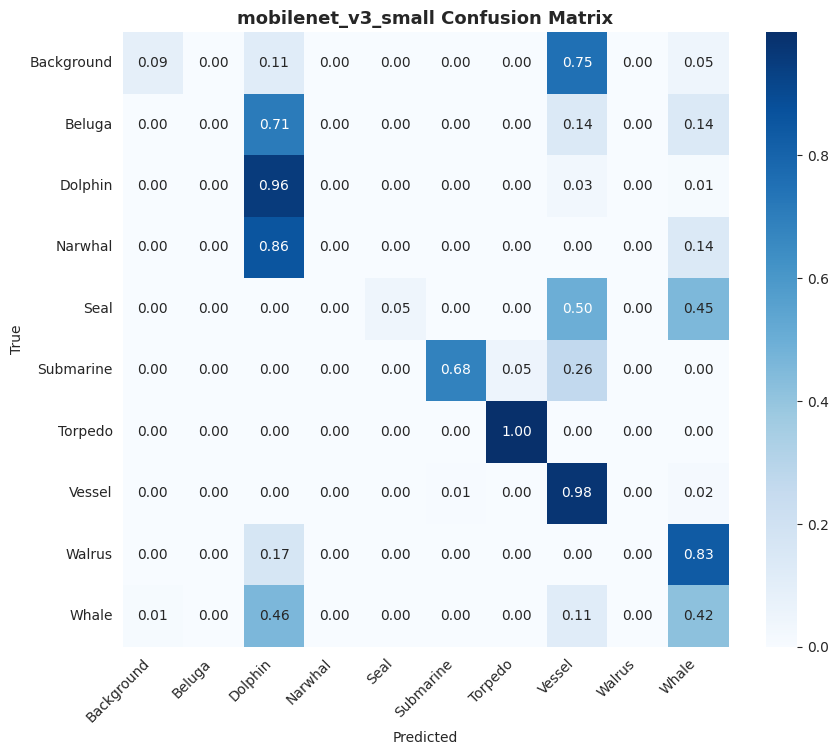


  Training: mobilenet_v3_large
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 116MB/s] 


  Total params    : 4,367,002
  Trainable (head): 165,258
Ep   1/35 | Train 1.7887/0.4881 | Val 1.7464/0.4926 F1=0.1454  ✓ saved
Ep   2/35 | Train 1.6699/0.5300 | Val 1.4446/0.6261 F1=0.2637  ✓ saved
Ep   3/35 | Train 1.6424/0.5305 | Val 1.3244/0.6513 F1=0.2948  ✓ saved
Ep   4/35 | Train 1.6306/0.5279 | Val 1.3102/0.6439 F1=0.3335  ✓ saved
Ep   5/35 | Train 1.6189/0.5368 | Val 1.3138/0.6617 F1=0.3600  ✓ saved
  → Unfreezing backbone for fine-tuning
Ep   6/35 | Train 1.6000/0.5502 | Val 1.2623/0.6810 F1=0.3541
Ep   7/35 | Train 1.5736/0.5470 | Val 1.2051/0.7003 F1=0.3484
Ep   8/35 | Train 1.5658/0.5562 | Val 1.1954/0.7047 F1=0.3452
Ep   9/35 | Train 1.5194/0.5850 | Val 1.1917/0.7033 F1=0.3459
Ep  10/35 | Train 1.5064/0.5903 | Val 1.1842/0.7122 F1=0.3801  ✓ saved
Ep  11/35 | Train 1.5021/0.5892 | Val 1.1682/0.7166 F1=0.3498
Ep  12/35 | Train 1.4742/0.5963 | Val 1.1457/0.7240 F1=0.3601
Ep  13/35 | Train 1.4712/0.5989 | Val 1.1431/0.7329 F1=0.3718
Ep  14/35 | Train 1.4606/0.6015 | Val 1.12

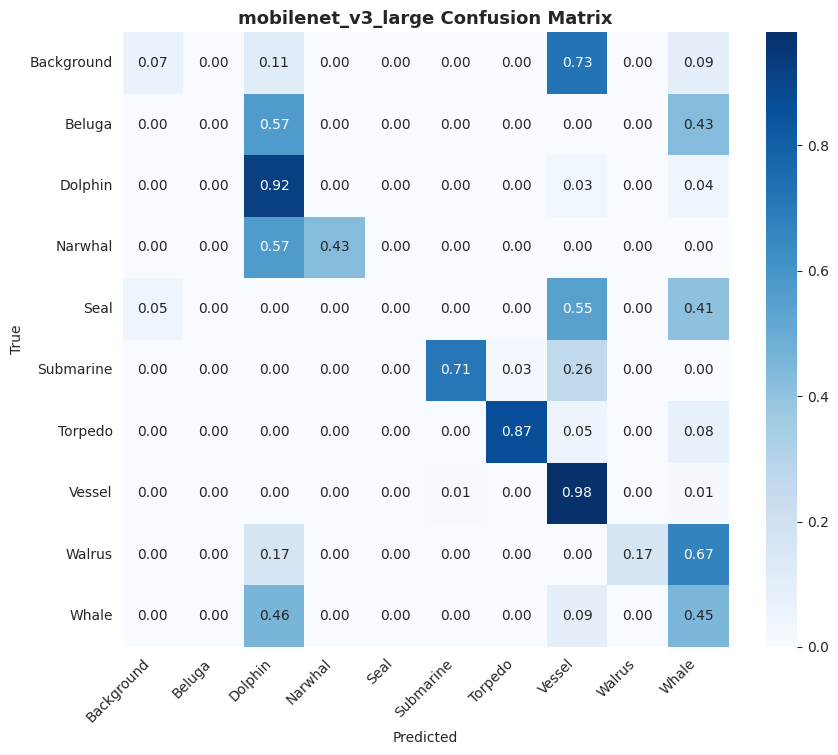


  Training: efficientnet_b0
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 122MB/s] 


  Total params    : 4,172,230
  Trainable (head): 165,258
Ep   1/35 | Train 1.7551/0.4870 | Val 1.4077/0.6187 F1=0.2380  ✓ saved
Ep   2/35 | Train 1.6406/0.5193 | Val 1.3461/0.6469 F1=0.2751  ✓ saved
Ep   3/35 | Train 1.6075/0.5439 | Val 1.3256/0.6469 F1=0.2827  ✓ saved
Ep   4/35 | Train 1.5983/0.5423 | Val 1.2968/0.6588 F1=0.3011  ✓ saved
Ep   5/35 | Train 1.5523/0.5643 | Val 1.2730/0.6602 F1=0.3113  ✓ saved
  → Unfreezing backbone for fine-tuning
Ep   6/35 | Train 1.5491/0.5612 | Val 1.2191/0.6736 F1=0.3141  ✓ saved
Ep   7/35 | Train 1.5134/0.5793 | Val 1.1778/0.7077 F1=0.3589  ✓ saved
Ep   8/35 | Train 1.4850/0.5916 | Val 1.1596/0.7315 F1=0.3784  ✓ saved
Ep   9/35 | Train 1.4764/0.5939 | Val 1.1302/0.7329 F1=0.3778
Ep  10/35 | Train 1.4563/0.5989 | Val 1.1110/0.7552 F1=0.4082  ✓ saved
Ep  11/35 | Train 1.4433/0.6157 | Val 1.0847/0.7478 F1=0.3991
Ep  12/35 | Train 1.4264/0.6162 | Val 1.0842/0.7418 F1=0.3982
Ep  13/35 | Train 1.4142/0.6154 | Val 1.0697/0.7493 F1=0.3944
Ep  14/35 | Tra

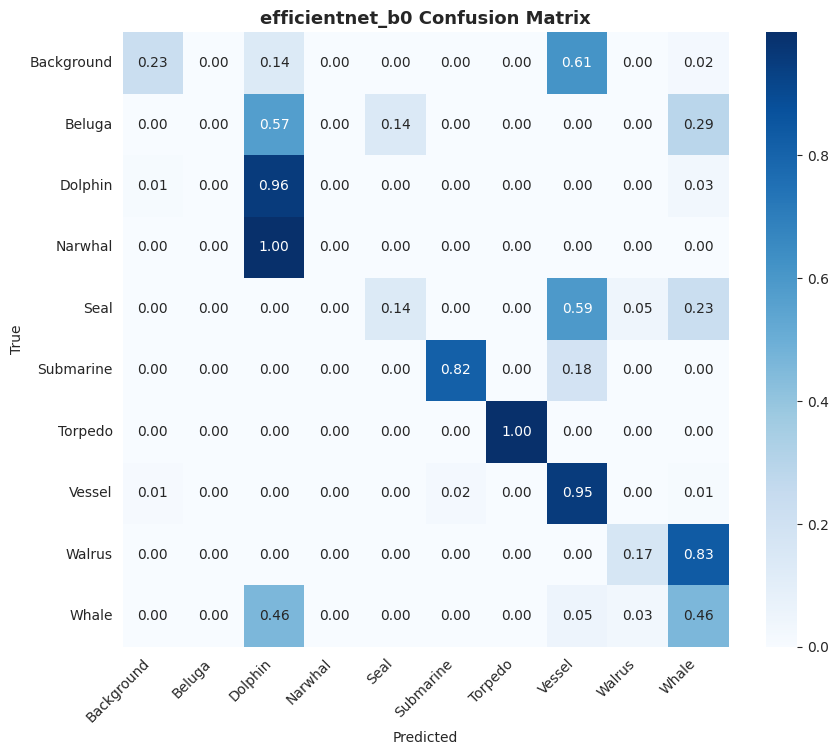


  Training: efficientnet_b1
Downloading: "https://download.pytorch.org/models/efficientnet_b1-c27df63c.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b1-c27df63c.pth


100%|██████████| 30.1M/30.1M [00:00<00:00, 150MB/s] 


  Total params    : 6,677,866
  Trainable (head): 165,258
Ep   1/35 | Train 1.7884/0.4708 | Val 1.4506/0.5564 F1=0.1807  ✓ saved
Ep   2/35 | Train 1.6662/0.5169 | Val 1.3568/0.6261 F1=0.2444  ✓ saved
Ep   3/35 | Train 1.6422/0.5245 | Val 1.3697/0.6409 F1=0.2693  ✓ saved
Ep   4/35 | Train 1.6517/0.5216 | Val 1.3238/0.6484 F1=0.3190  ✓ saved
Ep   5/35 | Train 1.6251/0.5308 | Val 1.2927/0.6706 F1=0.3338  ✓ saved
  → Unfreezing backbone for fine-tuning
Ep   6/35 | Train 1.5887/0.5439 | Val 1.2478/0.6840 F1=0.3324
Ep   7/35 | Train 1.5457/0.5604 | Val 1.4388/0.6840 F1=0.3653  ✓ saved
Ep   8/35 | Train 1.5254/0.5701 | Val 1.2057/0.7136 F1=0.3696  ✓ saved
Ep   9/35 | Train 1.5084/0.5832 | Val 1.2542/0.6958 F1=0.3547
Ep  10/35 | Train 1.4911/0.5829 | Val 1.2346/0.7062 F1=0.3701  ✓ saved
Ep  11/35 | Train 1.4959/0.5874 | Val 1.1616/0.7255 F1=0.3971  ✓ saved
Ep  12/35 | Train 1.4698/0.5952 | Val 1.1695/0.7077 F1=0.3788
Ep  13/35 | Train 1.4470/0.6052 | Val 1.1186/0.7300 F1=0.3815
Ep  14/35 | Tra

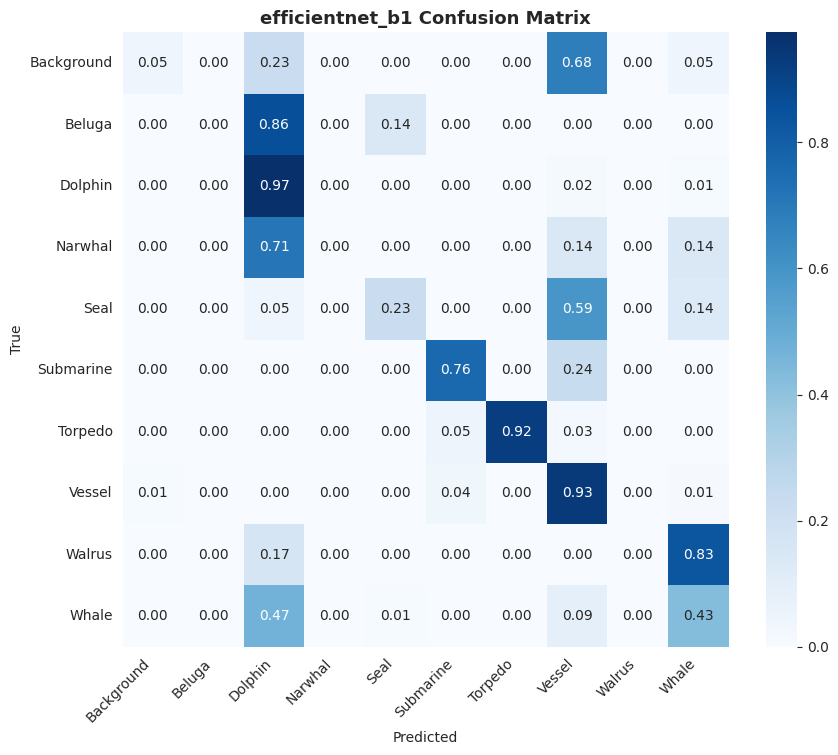


  Training: resnet18
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 140MB/s] 


  Total params    : 11,237,194
  Trainable (head): 66,954
Ep   1/35 | Train 1.7094/0.5069 | Val 1.2922/0.6617 F1=0.2728  ✓ saved
Ep   2/35 | Train 1.5848/0.5580 | Val 1.2076/0.7107 F1=0.3406  ✓ saved
Ep   3/35 | Train 1.5480/0.5601 | Val 1.1910/0.7300 F1=0.3847  ✓ saved
Ep   4/35 | Train 1.5271/0.5806 | Val 1.1668/0.7344 F1=0.3863  ✓ saved
Ep   5/35 | Train 1.5417/0.5680 | Val 1.1577/0.7196 F1=0.3478
  → Unfreezing backbone for fine-tuning
Ep   6/35 | Train 1.4602/0.6128 | Val 1.0046/0.7849 F1=0.4314  ✓ saved
Ep   7/35 | Train 1.3802/0.6416 | Val 0.9595/0.7893 F1=0.4769  ✓ saved
Ep   8/35 | Train 1.3224/0.6594 | Val 0.9020/0.8042 F1=0.5327  ✓ saved
Ep   9/35 | Train 1.3154/0.6639 | Val 0.8816/0.8234 F1=0.5623  ✓ saved
Ep  10/35 | Train 1.2957/0.6639 | Val 0.8466/0.8368 F1=0.5872  ✓ saved
Ep  11/35 | Train 1.2725/0.6812 | Val 0.8388/0.8442 F1=0.6025  ✓ saved
Ep  12/35 | Train 1.2565/0.6856 | Val 0.8077/0.8576 F1=0.6400  ✓ saved
Ep  13/35 | Train 1.2370/0.6940 | Val 0.8121/0.8472 F1=0.63

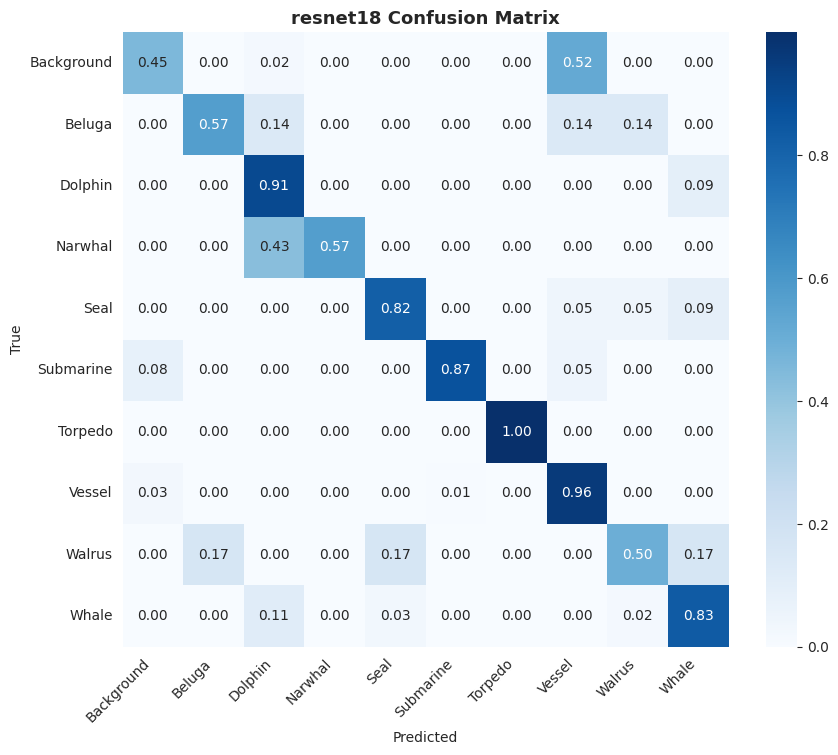


  Training: resnet34
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 169MB/s] 


  Total params    : 21,345,354
  Trainable (head): 66,954
Ep   1/35 | Train 1.7450/0.4938 | Val 1.4280/0.6113 F1=0.2508  ✓ saved
Ep   2/35 | Train 1.6278/0.5347 | Val 1.3069/0.6766 F1=0.3262  ✓ saved
Ep   3/35 | Train 1.6162/0.5371 | Val 1.2922/0.6691 F1=0.3427  ✓ saved
Ep   4/35 | Train 1.5823/0.5494 | Val 1.2478/0.6958 F1=0.3618  ✓ saved
Ep   5/35 | Train 1.5747/0.5591 | Val 1.2466/0.6855 F1=0.3295
  → Unfreezing backbone for fine-tuning
Ep   6/35 | Train 1.4774/0.6002 | Val 1.0169/0.7789 F1=0.4156  ✓ saved
Ep   7/35 | Train 1.3807/0.6356 | Val 0.9690/0.7982 F1=0.5547  ✓ saved
Ep   8/35 | Train 1.3461/0.6447 | Val 0.9058/0.8071 F1=0.5322
Ep   9/35 | Train 1.3288/0.6521 | Val 0.9016/0.8086 F1=0.5384
Ep  10/35 | Train 1.2916/0.6691 | Val 0.8470/0.8279 F1=0.6030  ✓ saved
Ep  11/35 | Train 1.2690/0.6744 | Val 0.8542/0.8249 F1=0.6204  ✓ saved
Ep  12/35 | Train 1.2727/0.6817 | Val 0.8417/0.8353 F1=0.6961  ✓ saved
Ep  13/35 | Train 1.2458/0.6872 | Val 0.8258/0.8294 F1=0.6714
Ep  14/35 | Tra

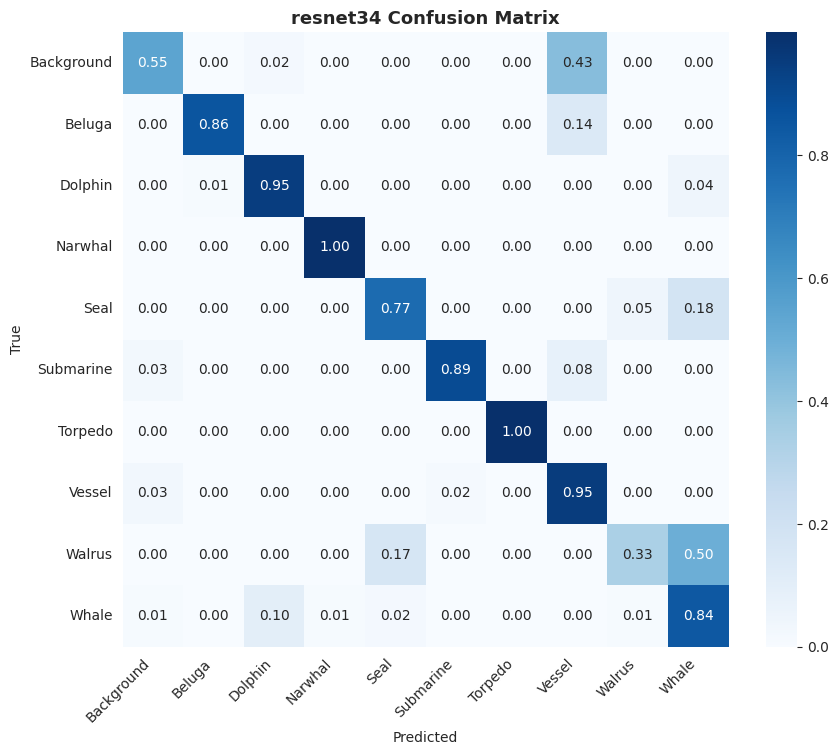


  Training: squeezenet1_1
Downloading: "https://download.pytorch.org/models/squeezenet1_1-b8a52dc0.pth" to /root/.cache/torch/hub/checkpoints/squeezenet1_1-b8a52dc0.pth


100%|██████████| 4.73M/4.73M [00:00<00:00, 54.6MB/s]

  Total params    : 1,050,890
  Trainable (head): 66,954


Ep   1/35 | Train 2.5052/0.3946 | Val 1.7461/0.5312 F1=0.1298  ✓ saved
Ep   2/35 | Train 1.8440/0.4650 | Val 1.6608/0.5223 F1=0.1178
Ep   3/35 | Train 1.7657/0.4868 | Val 1.5429/0.5757 F1=0.1492  ✓ saved
Ep   4/35 | Train 1.7390/0.4897 | Val 1.5710/0.5772 F1=0.1363
Ep   5/35 | Train 1.7366/0.4938 | Val 1.5157/0.5801 F1=0.1372
  → Unfreezing backbone for fine-tuning
Ep   6/35 | Train 1.6721/0.5090 | Val 1.4484/0.6009 F1=0.1432
Ep   7/35 | Train 1.6506/0.5117 | Val 1.3626/0.6068 F1=0.1442
Ep   8/35 | Train 1.6099/0.5269 | Val 1.3425/0.6098 F1=0.1448
Ep   9/35 | Train 1.5900/0.5276 | Val 1.3294/0.6128 F1=0.1457
Ep  10/35 | Train 1.5720/0.5313 | Val 1.3055/0.6142 F1=0.1459
Ep  11/35 | Train 1.5655/0.5392 | Val 1.2366/0.6662 F1=0.2468  ✓ saved
Ep  12/35 | Train 1.5465/0.5703 | Val 1.2004/0.7240 F1=0.2939  ✓ saved
Ep  13/35 | Train 1.4930/0.6075 | Val 1.1565/0.7226 F1=0.3041  ✓ saved
Ep  14/35 | Train 1.4957/0.6041 | Val 1.1179/0.7240 F1=0.2996
Ep  15/35 | Train 1.4834/0.6023 | Val 1.1241/0.

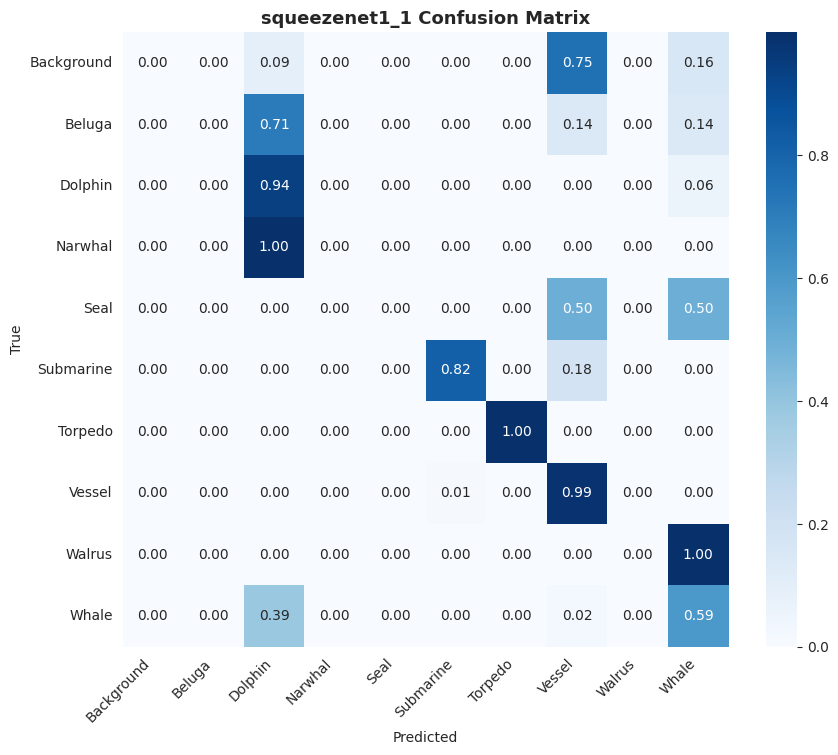

In [14]:
BACKBONES = [
    'mobilenet_v3_small',
    'mobilenet_v3_large',
    'efficientnet_b0',
    'efficientnet_b1',
    'resnet18',
    'resnet34',
    'squeezenet1_1',
]

WARMUP_EPOCHS  = 5
TOTAL_EPOCHS   = 35
PATIENCE       = 8

all_results = {}   # will hold {name: (labels, preds, history, param_count)}

for backbone_name in BACKBONES:
    print(f'\n{"="*60}')
    print(f'  Training: {backbone_name}')
    print(f'{"="*60}')

    model = PretrainedAcoustic(num_classes=NUM_CLASSES,
                               backbone_name=backbone_name).to(DEVICE)
    model.freeze_backbone()

    n_params = count_params(model)
    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  Total params    : {n_params:,}')
    print(f'  Trainable (head): {n_trainable:,}')

    history, val_labels, val_preds = train(
        model, train_loader, val_loader,
        num_epochs=TOTAL_EPOCHS,
        lr=1e-3,
        patience=PATIENCE,
        save_path=f'best_{backbone_name}.pth',
        warmup_epochs=WARMUP_EPOCHS,
        warmup_lr=1e-3,
        finetune_lr=5e-5,
        device=DEVICE
    )

    # Reload best checkpoint and get final predictions
    model.load_state_dict(torch.load(f'best_{backbone_name}.pth'))
    final_labels, final_preds = evaluate(model, val_loader)

    all_results[backbone_name] = {
        'labels':   final_labels,
        'preds':    final_preds,
        'history':  history,
        'n_params': n_params,
    }

    # Per-model confusion matrix
    plot_confusion(final_labels, final_preds, CLASS_NAMES,
                   title=f'{backbone_name} Confusion Matrix')

    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

## 10 · Evaluation & Visualizations


─── AcousticCNN ───────────────────────────────
  Accuracy : 0.9021
  Precision: 0.8751
  Recall   : 0.8123
  F1 macro : 0.8305
              precision    recall  f1-score   support

  Background       0.72      0.59      0.65        44
      Beluga       1.00      0.43      0.60         7
     Dolphin       0.87      0.97      0.91       116
     Narwhal       1.00      1.00      1.00         7
        Seal       0.86      0.82      0.84        22
   Submarine       0.89      0.89      0.89        38
     Torpedo       1.00      1.00      1.00        38
      Vessel       0.93      0.97      0.95       300
      Walrus       0.57      0.67      0.62         6
       Whale       0.90      0.79      0.84        96

    accuracy                           0.90       674
   macro avg       0.88      0.81      0.83       674
weighted avg       0.90      0.90      0.90       674



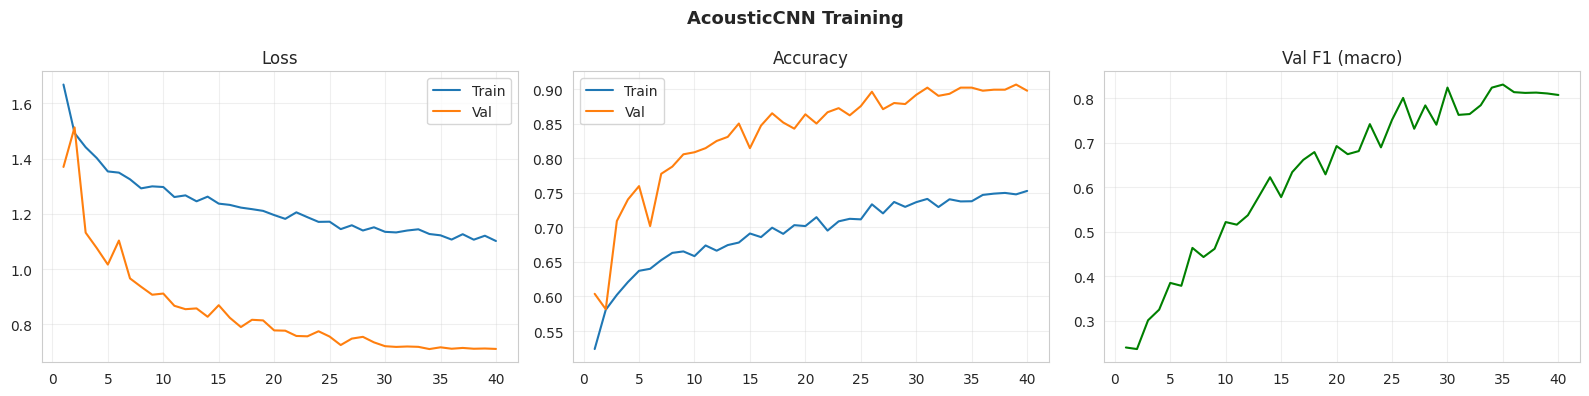

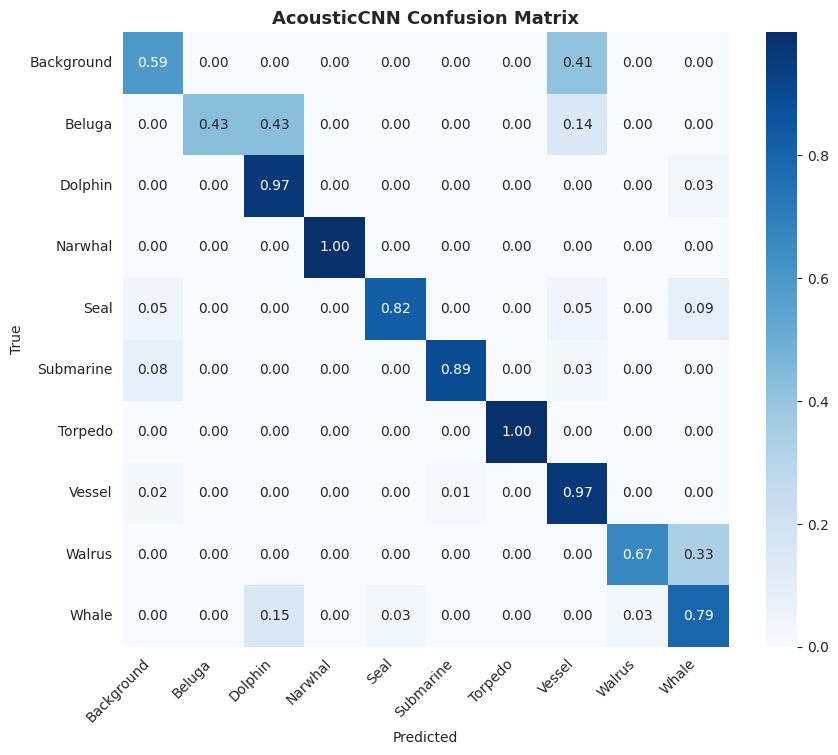


─── mobilenet_v3_small ───────────────────────────────
  Accuracy : 0.7611
  Precision: 0.5746
  Recall   : 0.4171
  F1 macro : 0.4164
              precision    recall  f1-score   support

  Background       0.80      0.09      0.16        44
      Beluga       0.00      0.00      0.00         7
     Dolphin       0.65      0.96      0.77       116
     Narwhal       0.00      0.00      0.00         7
        Seal       1.00      0.05      0.09        22
   Submarine       0.93      0.68      0.79        38
     Torpedo       0.95      1.00      0.97        38
      Vessel       0.81      0.98      0.88       300
      Walrus       0.00      0.00      0.00         6
       Whale       0.62      0.42      0.50        96

    accuracy                           0.76       674
   macro avg       0.57      0.42      0.42       674
weighted avg       0.75      0.76      0.71       674



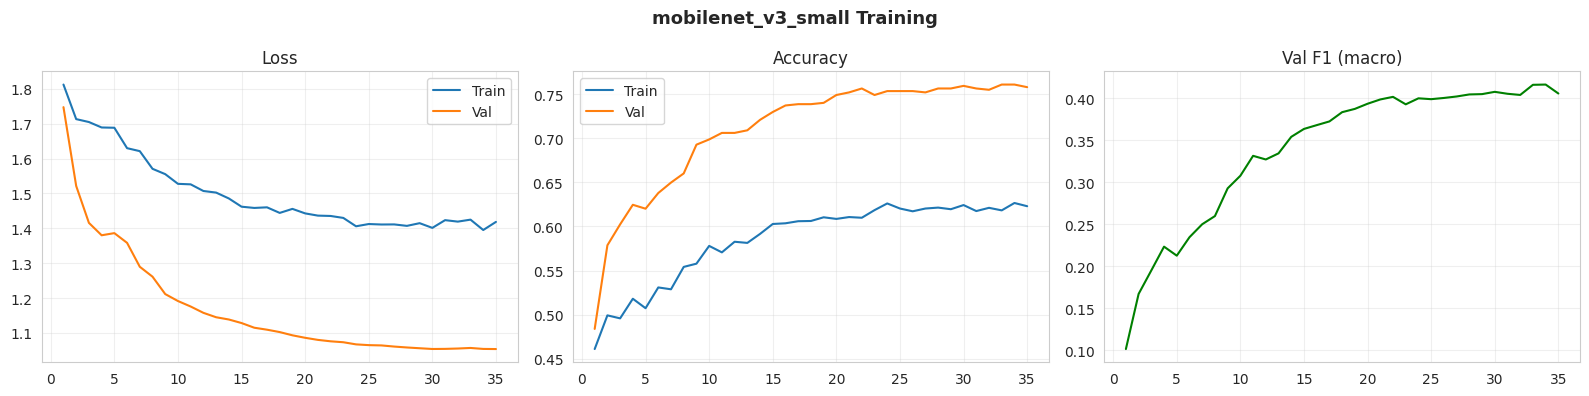

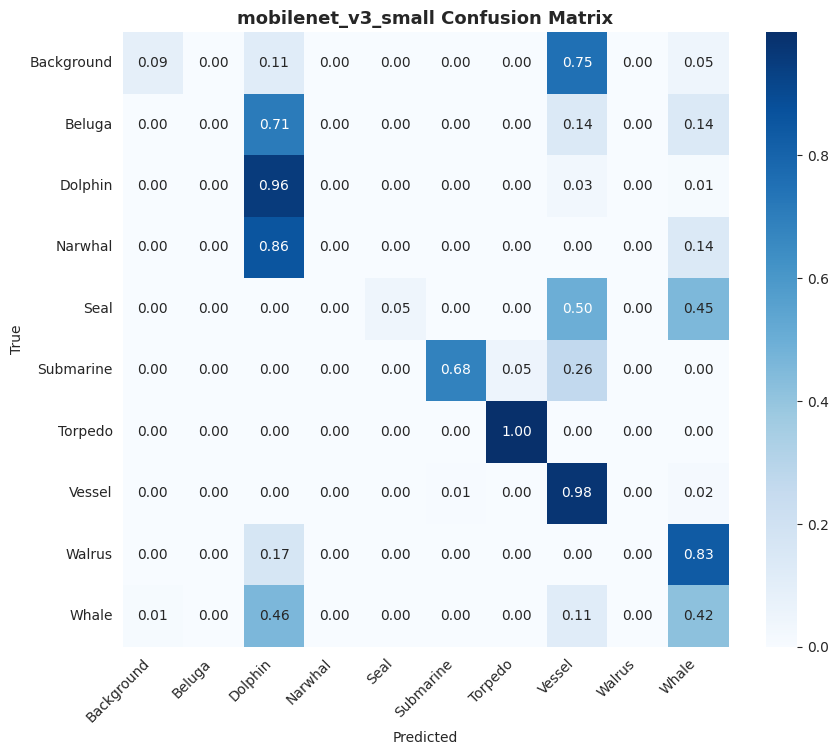


─── mobilenet_v3_large ───────────────────────────────
  Accuracy : 0.7582
  Precision: 0.6683
  Recall   : 0.4593
  F1 macro : 0.4885
              precision    recall  f1-score   support

  Background       0.75      0.07      0.12        44
      Beluga       0.00      0.00      0.00         7
     Dolphin       0.65      0.92      0.76       116
     Narwhal       1.00      0.43      0.60         7
        Seal       0.00      0.00      0.00        22
   Submarine       0.93      0.71      0.81        38
     Torpedo       0.97      0.87      0.92        38
      Vessel       0.81      0.98      0.89       300
      Walrus       1.00      0.17      0.29         6
       Whale       0.57      0.45      0.50        96

    accuracy                           0.76       674
   macro avg       0.67      0.46      0.49       674
weighted avg       0.73      0.76      0.71       674



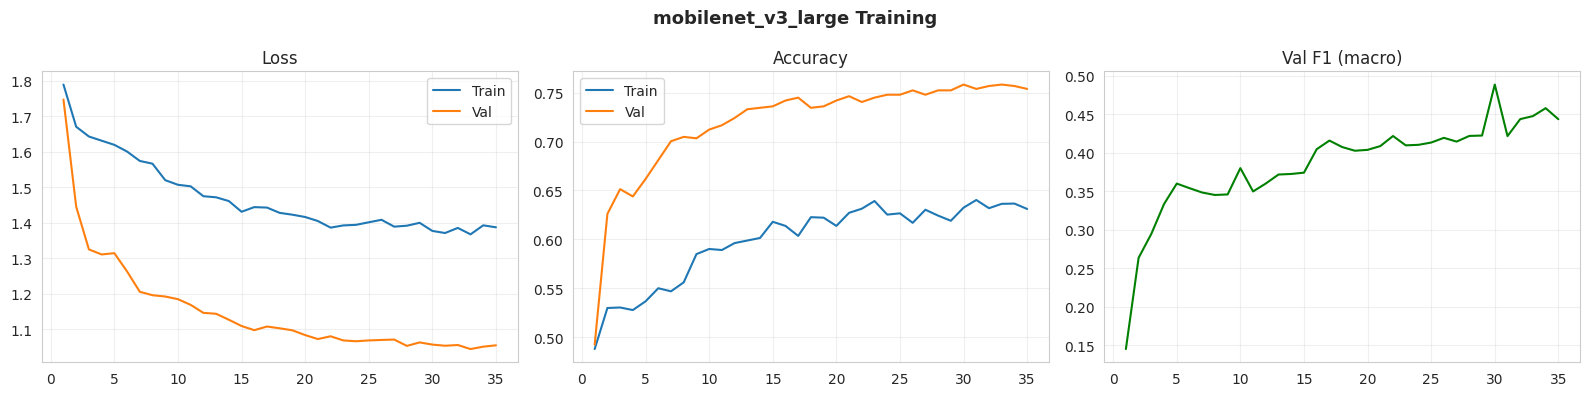

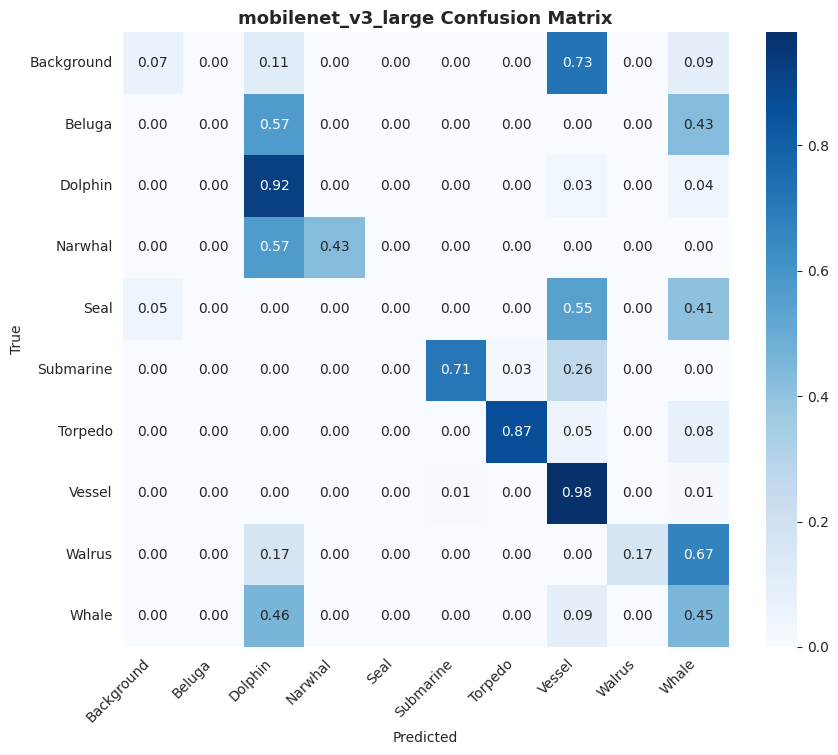


─── efficientnet_b0 ───────────────────────────────
  Accuracy : 0.7774
  Precision: 0.5611
  Recall   : 0.4715
  F1 macro : 0.4785
              precision    recall  f1-score   support

  Background       0.67      0.23      0.34        44
      Beluga       0.00      0.00      0.00         7
     Dolphin       0.65      0.96      0.77       116
     Narwhal       0.00      0.00      0.00         7
        Seal       0.75      0.14      0.23        22
   Submarine       0.82      0.82      0.82        38
     Torpedo       1.00      1.00      1.00        38
      Vessel       0.85      0.95      0.90       300
      Walrus       0.20      0.17      0.18         6
       Whale       0.69      0.46      0.55        96

    accuracy                           0.78       674
   macro avg       0.56      0.47      0.48       674
weighted avg       0.76      0.78      0.74       674



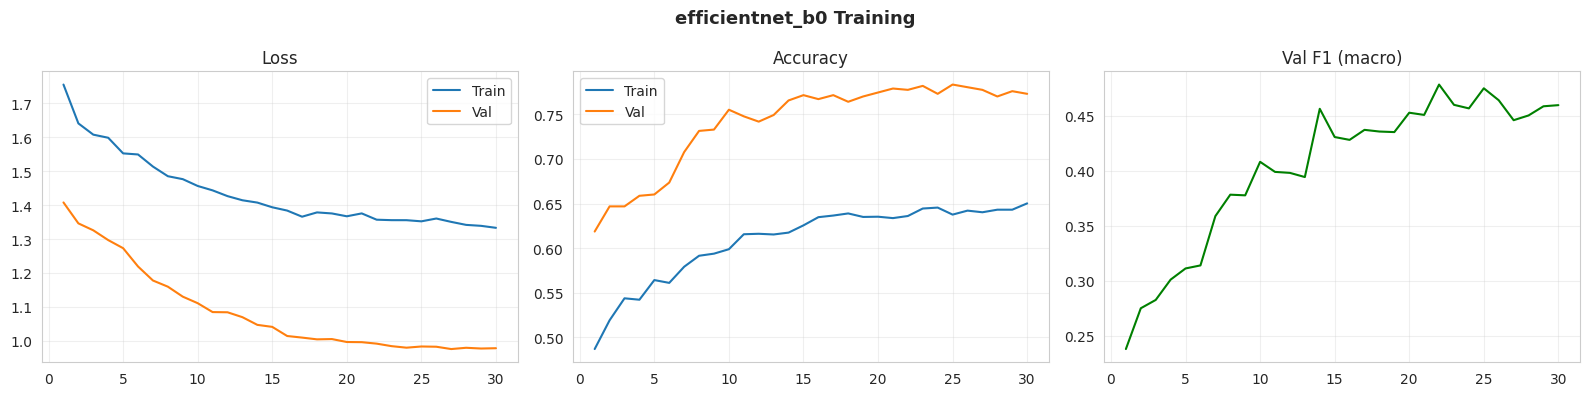

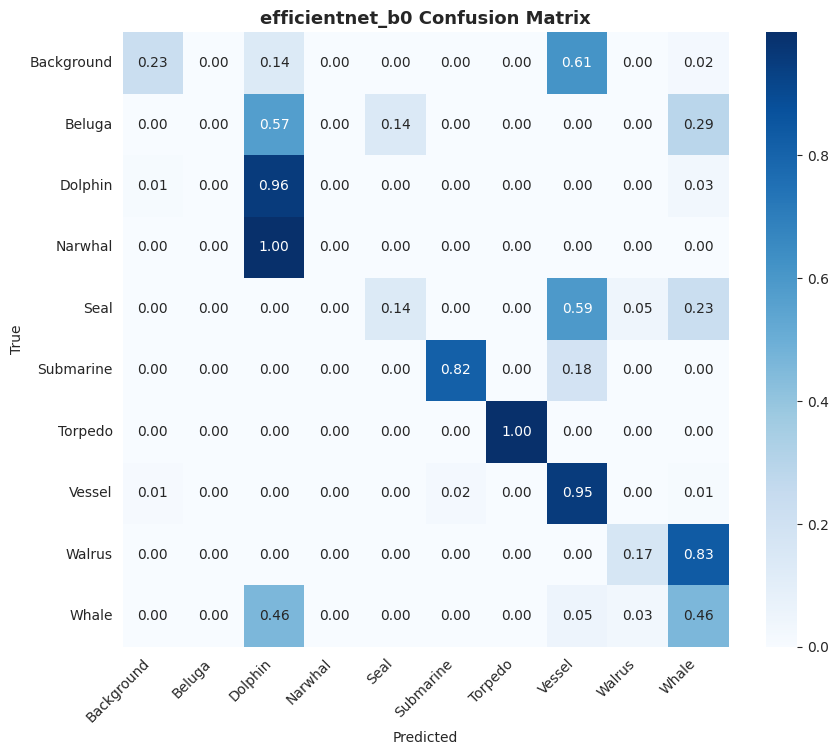


─── efficientnet_b1 ───────────────────────────────
  Accuracy : 0.7493
  Precision: 0.4916
  Recall   : 0.4291
  F1 macro : 0.4254
              precision    recall  f1-score   support

  Background       0.40      0.05      0.08        44
      Beluga       0.00      0.00      0.00         7
     Dolphin       0.62      0.97      0.76       116
     Narwhal       0.00      0.00      0.00         7
        Seal       0.71      0.23      0.34        22
   Submarine       0.67      0.76      0.72        38
     Torpedo       0.97      0.92      0.95        38
      Vessel       0.81      0.93      0.87       300
      Walrus       0.00      0.00      0.00         6
       Whale       0.72      0.43      0.54        96

    accuracy                           0.75       674
   macro avg       0.49      0.43      0.43       674
weighted avg       0.71      0.75      0.70       674



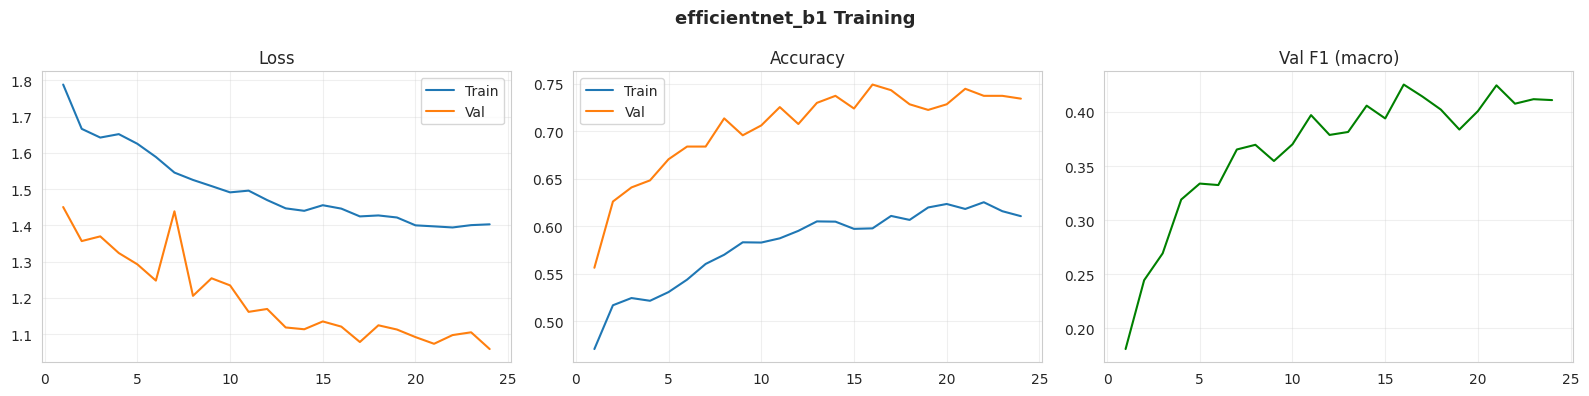

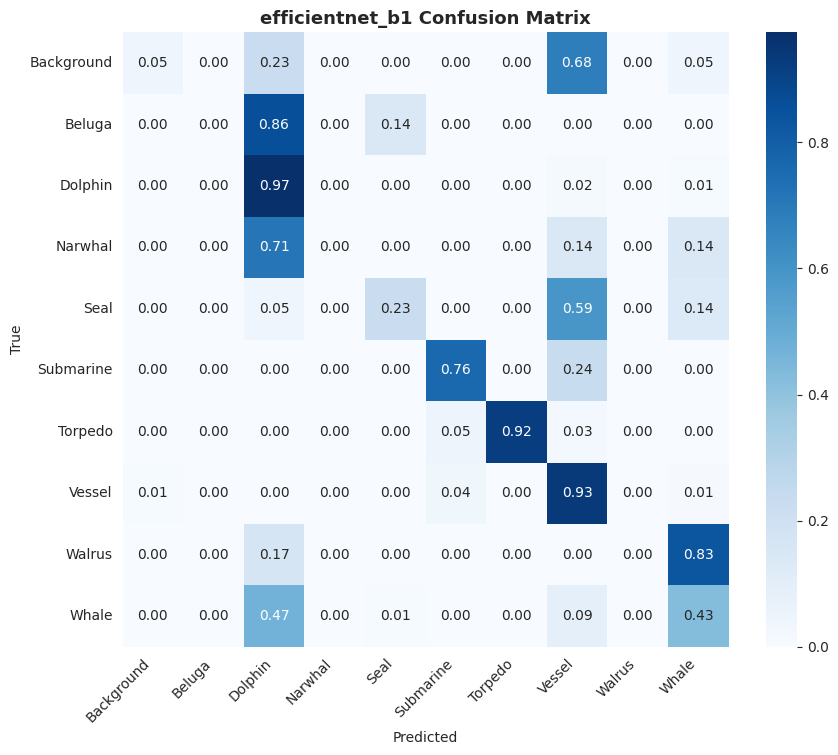


─── resnet18 ───────────────────────────────
  Accuracy : 0.8798
  Precision: 0.8239
  Recall   : 0.7483
  F1 macro : 0.7764
              precision    recall  f1-score   support

  Background       0.62      0.45      0.53        44
      Beluga       0.80      0.57      0.67         7
     Dolphin       0.87      0.91      0.89       116
     Narwhal       1.00      0.57      0.73         7
        Seal       0.82      0.82      0.82        22
   Submarine       0.94      0.87      0.90        38
     Torpedo       1.00      1.00      1.00        38
      Vessel       0.91      0.96      0.94       300
      Walrus       0.43      0.50      0.46         6
       Whale       0.84      0.83      0.84        96

    accuracy                           0.88       674
   macro avg       0.82      0.75      0.78       674
weighted avg       0.88      0.88      0.88       674



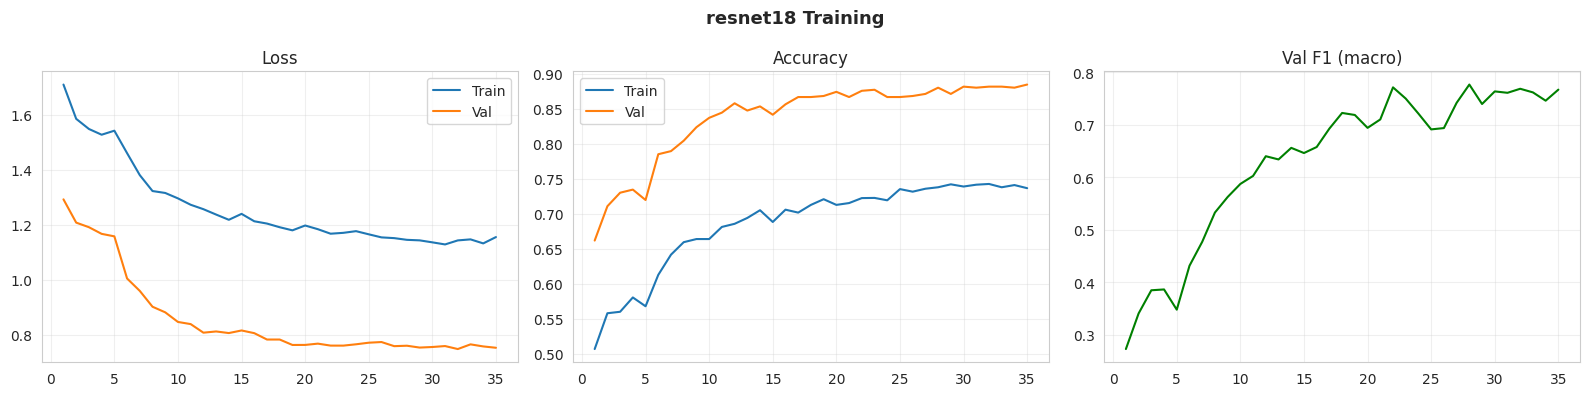

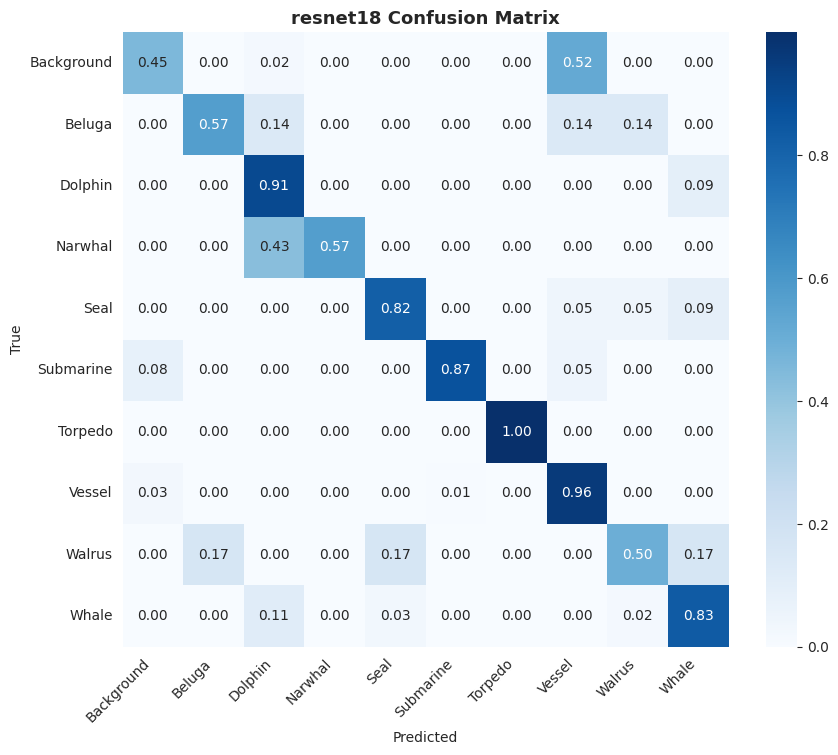


─── resnet34 ───────────────────────────────
  Accuracy : 0.8961
  Precision: 0.8326
  Recall   : 0.8145
  F1 macro : 0.8206
              precision    recall  f1-score   support

  Background       0.67      0.55      0.60        44
      Beluga       0.86      0.86      0.86         7
     Dolphin       0.91      0.95      0.93       116
     Narwhal       0.88      1.00      0.93         7
        Seal       0.85      0.77      0.81        22
   Submarine       0.87      0.89      0.88        38
     Torpedo       1.00      1.00      1.00        38
      Vessel       0.93      0.95      0.94       300
      Walrus       0.50      0.33      0.40         6
       Whale       0.87      0.84      0.86        96

    accuracy                           0.90       674
   macro avg       0.83      0.81      0.82       674
weighted avg       0.89      0.90      0.89       674



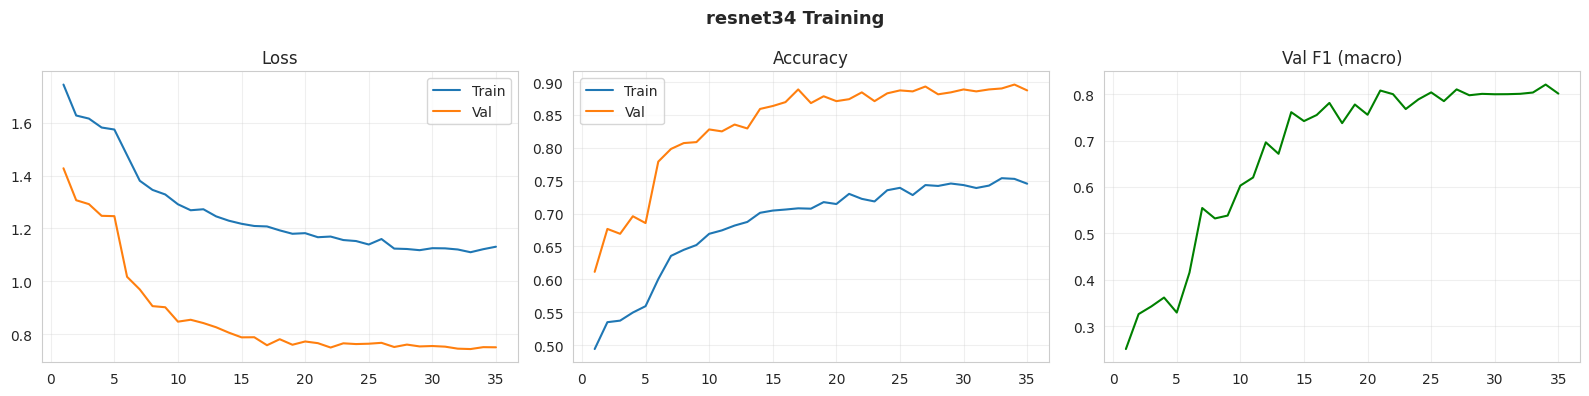

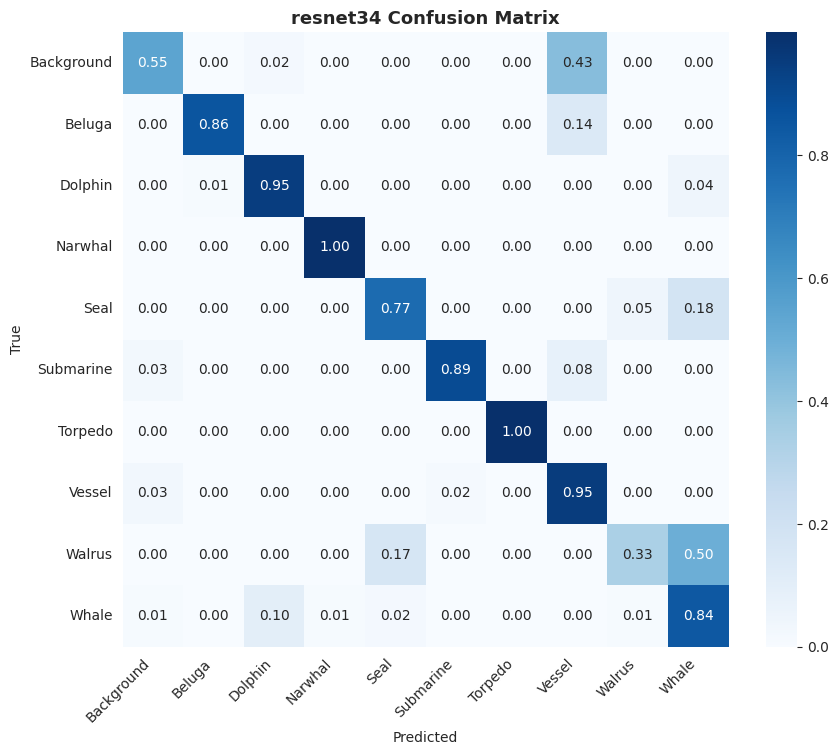


─── squeezenet1_1 ───────────────────────────────
  Accuracy : 0.7878
  Precision: 0.4045
  Recall   : 0.4336
  F1 macro : 0.4160
              precision    recall  f1-score   support

  Background       0.00      0.00      0.00        44
      Beluga       0.00      0.00      0.00         7
     Dolphin       0.67      0.94      0.78       116
     Narwhal       0.00      0.00      0.00         7
        Seal       0.00      0.00      0.00        22
   Submarine       0.89      0.82      0.85        38
     Torpedo       1.00      1.00      1.00        38
      Vessel       0.85      0.99      0.91       300
      Walrus       0.00      0.00      0.00         6
       Whale       0.64      0.59      0.62        96

    accuracy                           0.79       674
   macro avg       0.40      0.43      0.42       674
weighted avg       0.69      0.79      0.73       674



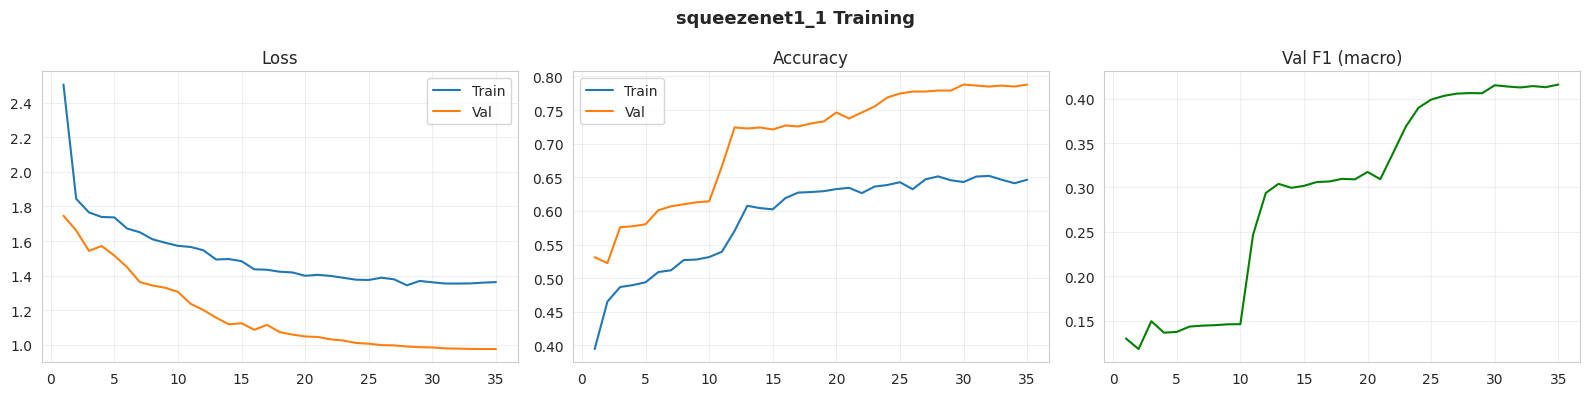

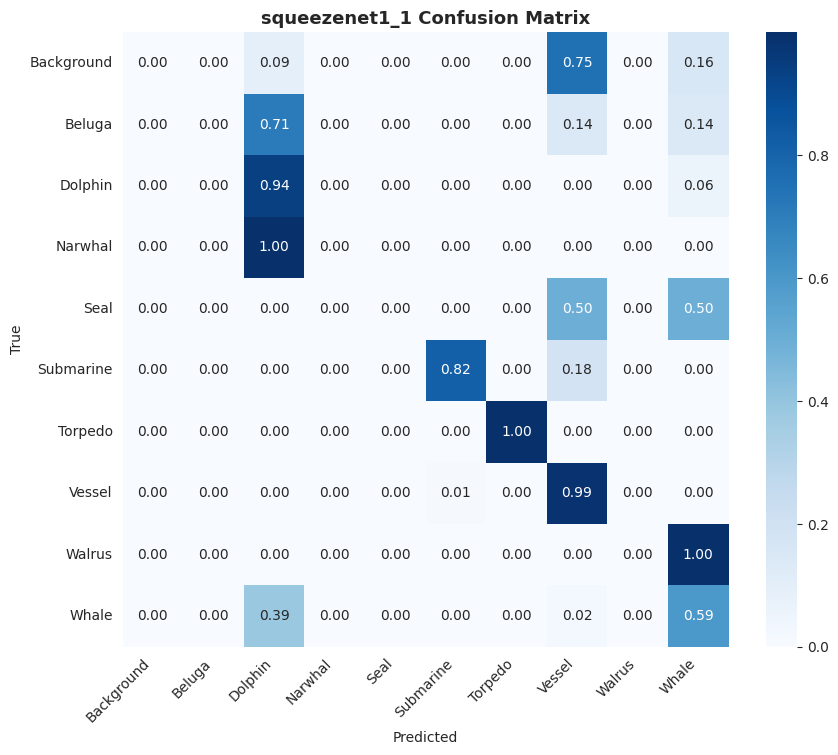

In [15]:
# ── AcousticCNN results ───────────────────────────────────────
lbl_cnn, pr_cnn = evaluate(model_cnn, val_loader)
print_metrics(lbl_cnn, pr_cnn, 'AcousticCNN')
plot_history(history_cnn, 'AcousticCNN Training')
plot_confusion(lbl_cnn, pr_cnn, CLASS_NAMES, 'AcousticCNN Confusion Matrix')

# ── All pretrained backbones ──────────────────────────────────
for backbone_name, res in all_results.items():
    print_metrics(res['labels'], res['preds'], backbone_name)
    plot_history(res['history'], f'{backbone_name} Training')
    plot_confusion(res['labels'], res['preds'], CLASS_NAMES,
                   f'{backbone_name} Confusion Matrix')

## 11 · Model Comparison

                        Params  Accuracy  Precision  Recall      F1
Model                                                              
AcousticCNN (proposed)   2.10M    0.9021     0.8751  0.8123  0.8305
resnet34                21.35M    0.8961     0.8326  0.8145  0.8206
resnet18                11.24M    0.8798     0.8239  0.7483  0.7764
mobilenet_v3_large       4.37M    0.7582     0.6683  0.4593  0.4885
efficientnet_b0          4.17M    0.7774     0.5611  0.4715  0.4785
efficientnet_b1          6.68M    0.7493     0.4916  0.4291  0.4254
mobilenet_v3_small       1.65M    0.7611     0.5746  0.4171  0.4164
squeezenet1_1            1.05M    0.7878     0.4045  0.4336  0.4160


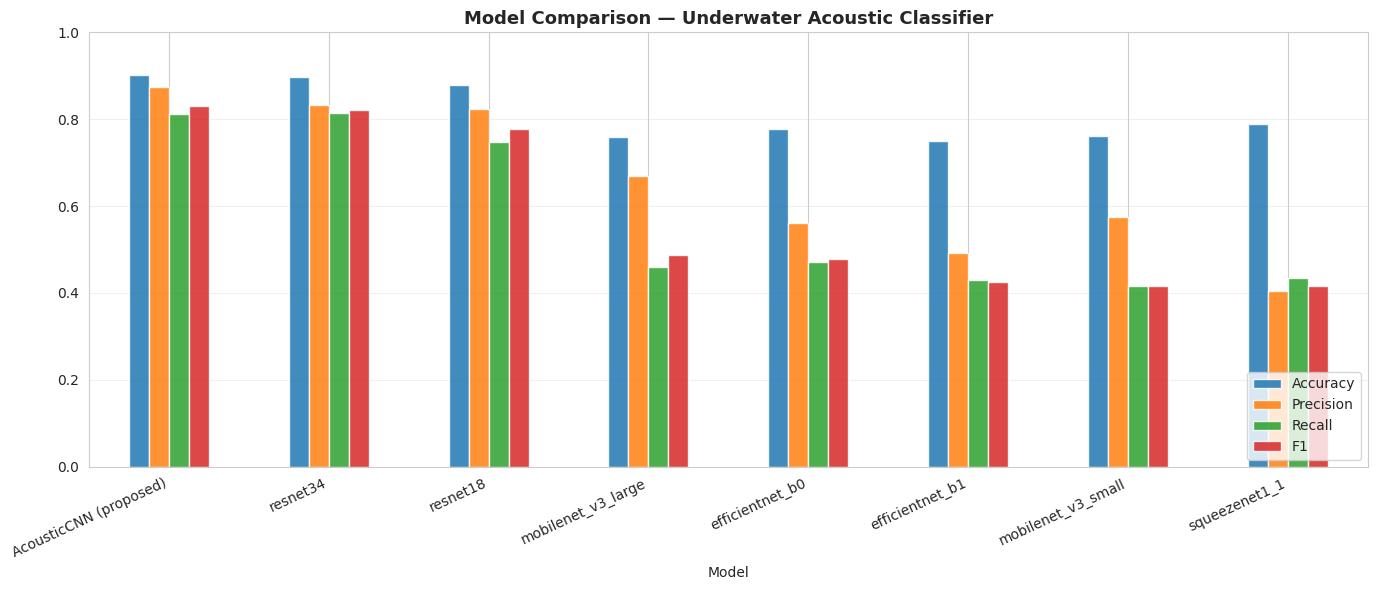

In [16]:
def full_comparison_table(cnn_labels, cnn_preds, cnn_params, pretrained_results: dict):
    rows = []

    # AcousticCNN row
    rows.append({
        'Model':      'AcousticCNN (proposed)',
        'Params':      cnn_params,
        'Accuracy':    accuracy_score(cnn_labels, cnn_preds),
        'Precision':   precision_score(cnn_labels, cnn_preds, average='macro', zero_division=0),
        'Recall':      recall_score(cnn_labels, cnn_preds, average='macro', zero_division=0),
        'F1':          f1_score(cnn_labels, cnn_preds, average='macro', zero_division=0),
    })

    # Pretrained rows
    for name, res in pretrained_results.items():
        rows.append({
            'Model':     name,
            'Params':    res['n_params'],
            'Accuracy':  accuracy_score(res['labels'], res['preds']),
            'Precision': precision_score(res['labels'], res['preds'], average='macro', zero_division=0),
            'Recall':    recall_score(res['labels'], res['preds'], average='macro', zero_division=0),
            'F1':        f1_score(res['labels'], res['preds'], average='macro', zero_division=0),
        })

    df = pd.DataFrame(rows).set_index('Model').sort_values('F1', ascending=False)
    df['Params'] = df['Params'].apply(lambda x: f'{x/1e6:.2f}M')
    print(df.round(4).to_string())

    # Bar chart — metrics only (no Params column)
    plot_df = df[['Accuracy', 'Precision', 'Recall', 'F1']].astype(float)
    ax = plot_df.plot(kind='bar', figsize=(14, 6), ylim=(0, 1), alpha=0.85)
    ax.set_title('Model Comparison — Underwater Acoustic Classifier',
                 fontsize=13, fontweight='bold')
    ax.set_xticklabels(plot_df.index, rotation=25, ha='right')
    ax.legend(loc='lower right')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('full_model_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    return df


comparison_df = full_comparison_table(
    cnn_labels=lbl_cnn,
    cnn_preds=pr_cnn,
    cnn_params=count_params(model_cnn),
    pretrained_results=all_results
)

# Testing other pretrained models


─── Test Results: AcousticCNN ───────────────────
  Accuracy  : 0.9021
  Precision : 0.8751
  Recall    : 0.8123
  F1 macro  : 0.8305
  Avg latency: 0.276 ms/sample
              precision    recall  f1-score   support

  Background       0.72      0.59      0.65        44
      Beluga       1.00      0.43      0.60         7
     Dolphin       0.87      0.97      0.91       116
     Narwhal       1.00      1.00      1.00         7
        Seal       0.86      0.82      0.84        22
   Submarine       0.89      0.89      0.89        38
     Torpedo       1.00      1.00      1.00        38
      Vessel       0.93      0.97      0.95       300
      Walrus       0.57      0.67      0.62         6
       Whale       0.90      0.79      0.84        96

    accuracy                           0.90       674
   macro avg       0.88      0.81      0.83       674
weighted avg       0.90      0.90      0.90       674



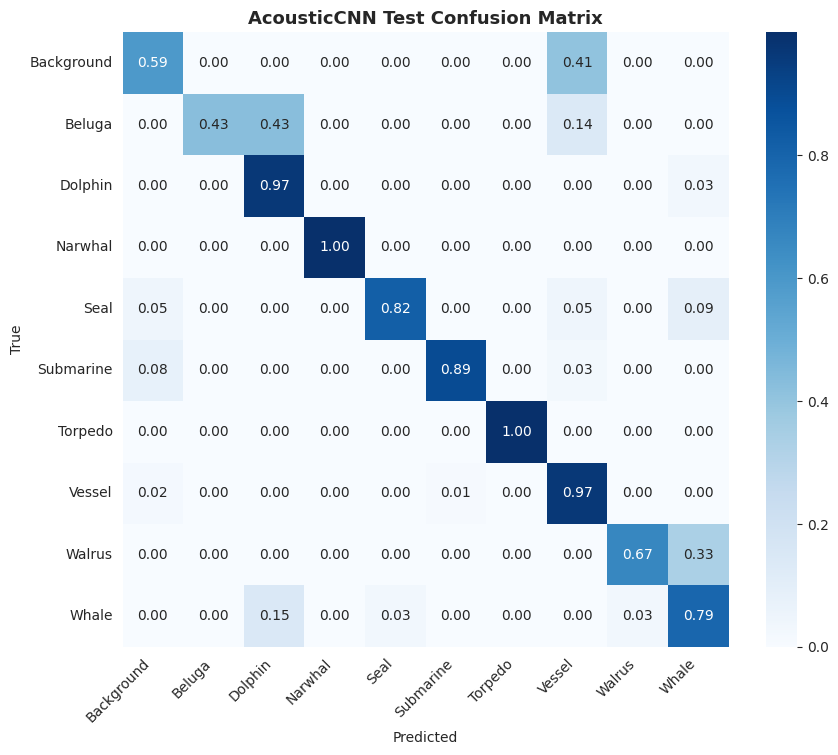


─── Test Results: mobilenet_v3_small ───────────────────
  Accuracy  : 0.7611
  Precision : 0.5746
  Recall    : 0.4171
  F1 macro  : 0.4164
  Avg latency: 0.476 ms/sample
              precision    recall  f1-score   support

  Background       0.80      0.09      0.16        44
      Beluga       0.00      0.00      0.00         7
     Dolphin       0.65      0.96      0.77       116
     Narwhal       0.00      0.00      0.00         7
        Seal       1.00      0.05      0.09        22
   Submarine       0.93      0.68      0.79        38
     Torpedo       0.95      1.00      0.97        38
      Vessel       0.81      0.98      0.88       300
      Walrus       0.00      0.00      0.00         6
       Whale       0.62      0.42      0.50        96

    accuracy                           0.76       674
   macro avg       0.57      0.42      0.42       674
weighted avg       0.75      0.76      0.71       674



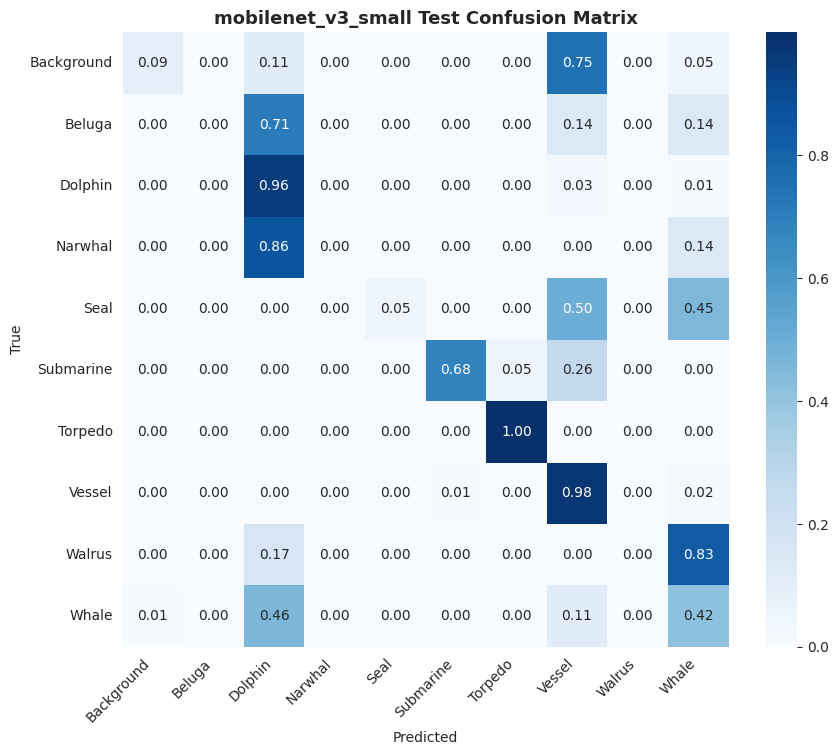


─── Test Results: mobilenet_v3_large ───────────────────
  Accuracy  : 0.7582
  Precision : 0.6683
  Recall    : 0.4593
  F1 macro  : 0.4885
  Avg latency: 0.494 ms/sample
              precision    recall  f1-score   support

  Background       0.75      0.07      0.12        44
      Beluga       0.00      0.00      0.00         7
     Dolphin       0.65      0.92      0.76       116
     Narwhal       1.00      0.43      0.60         7
        Seal       0.00      0.00      0.00        22
   Submarine       0.93      0.71      0.81        38
     Torpedo       0.97      0.87      0.92        38
      Vessel       0.81      0.98      0.89       300
      Walrus       1.00      0.17      0.29         6
       Whale       0.57      0.45      0.50        96

    accuracy                           0.76       674
   macro avg       0.67      0.46      0.49       674
weighted avg       0.73      0.76      0.71       674



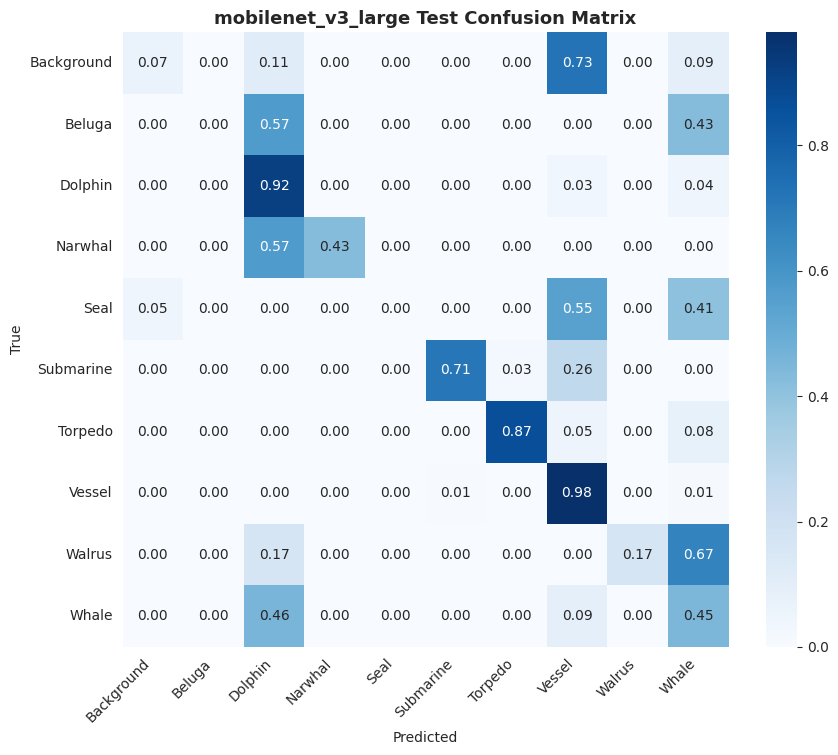


─── Test Results: efficientnet_b0 ───────────────────
  Accuracy  : 0.7774
  Precision : 0.5611
  Recall    : 0.4715
  F1 macro  : 0.4785
  Avg latency: 0.694 ms/sample
              precision    recall  f1-score   support

  Background       0.67      0.23      0.34        44
      Beluga       0.00      0.00      0.00         7
     Dolphin       0.65      0.96      0.77       116
     Narwhal       0.00      0.00      0.00         7
        Seal       0.75      0.14      0.23        22
   Submarine       0.82      0.82      0.82        38
     Torpedo       1.00      1.00      1.00        38
      Vessel       0.85      0.95      0.90       300
      Walrus       0.20      0.17      0.18         6
       Whale       0.69      0.46      0.55        96

    accuracy                           0.78       674
   macro avg       0.56      0.47      0.48       674
weighted avg       0.76      0.78      0.74       674



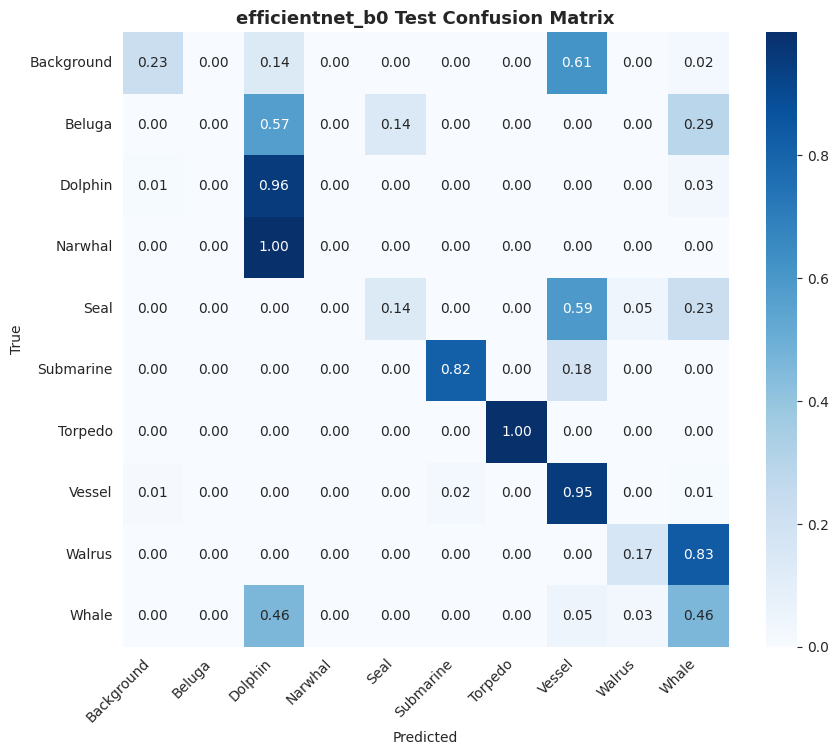


─── Test Results: efficientnet_b1 ───────────────────
  Accuracy  : 0.7493
  Precision : 0.4916
  Recall    : 0.4291
  F1 macro  : 0.4254
  Avg latency: 1.017 ms/sample
              precision    recall  f1-score   support

  Background       0.40      0.05      0.08        44
      Beluga       0.00      0.00      0.00         7
     Dolphin       0.62      0.97      0.76       116
     Narwhal       0.00      0.00      0.00         7
        Seal       0.71      0.23      0.34        22
   Submarine       0.67      0.76      0.72        38
     Torpedo       0.97      0.92      0.95        38
      Vessel       0.81      0.93      0.87       300
      Walrus       0.00      0.00      0.00         6
       Whale       0.72      0.43      0.54        96

    accuracy                           0.75       674
   macro avg       0.49      0.43      0.43       674
weighted avg       0.71      0.75      0.70       674



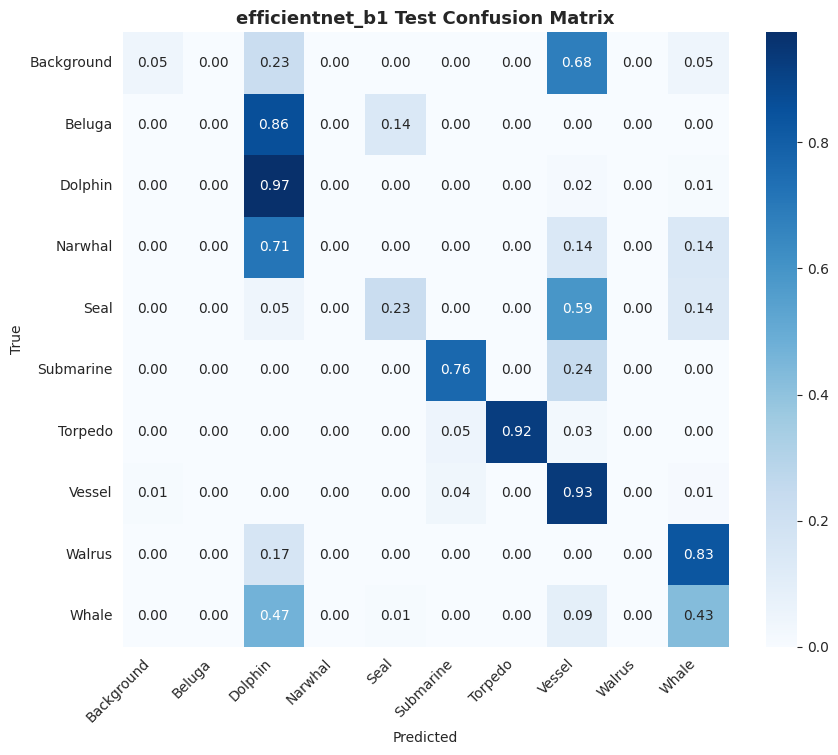


─── Test Results: resnet18 ───────────────────
  Accuracy  : 0.8798
  Precision : 0.8239
  Recall    : 0.7483
  F1 macro  : 0.7764
  Avg latency: 0.243 ms/sample
              precision    recall  f1-score   support

  Background       0.62      0.45      0.53        44
      Beluga       0.80      0.57      0.67         7
     Dolphin       0.87      0.91      0.89       116
     Narwhal       1.00      0.57      0.73         7
        Seal       0.82      0.82      0.82        22
   Submarine       0.94      0.87      0.90        38
     Torpedo       1.00      1.00      1.00        38
      Vessel       0.91      0.96      0.94       300
      Walrus       0.43      0.50      0.46         6
       Whale       0.84      0.83      0.84        96

    accuracy                           0.88       674
   macro avg       0.82      0.75      0.78       674
weighted avg       0.88      0.88      0.88       674



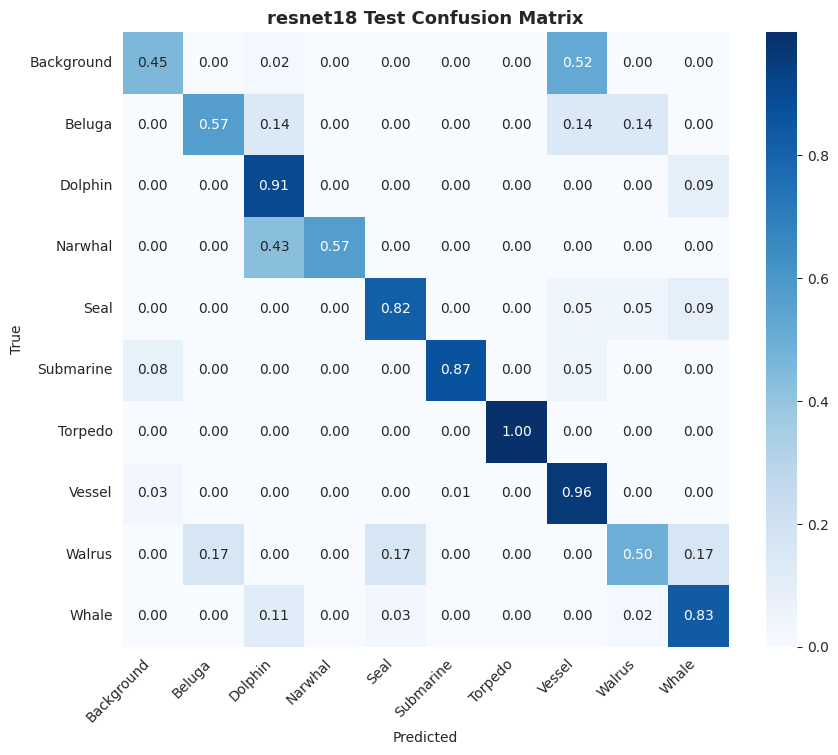


─── Test Results: resnet34 ───────────────────
  Accuracy  : 0.8961
  Precision : 0.8326
  Recall    : 0.8145
  F1 macro  : 0.8206
  Avg latency: 0.321 ms/sample
              precision    recall  f1-score   support

  Background       0.67      0.55      0.60        44
      Beluga       0.86      0.86      0.86         7
     Dolphin       0.91      0.95      0.93       116
     Narwhal       0.88      1.00      0.93         7
        Seal       0.85      0.77      0.81        22
   Submarine       0.87      0.89      0.88        38
     Torpedo       1.00      1.00      1.00        38
      Vessel       0.93      0.95      0.94       300
      Walrus       0.50      0.33      0.40         6
       Whale       0.87      0.84      0.86        96

    accuracy                           0.90       674
   macro avg       0.83      0.81      0.82       674
weighted avg       0.89      0.90      0.89       674



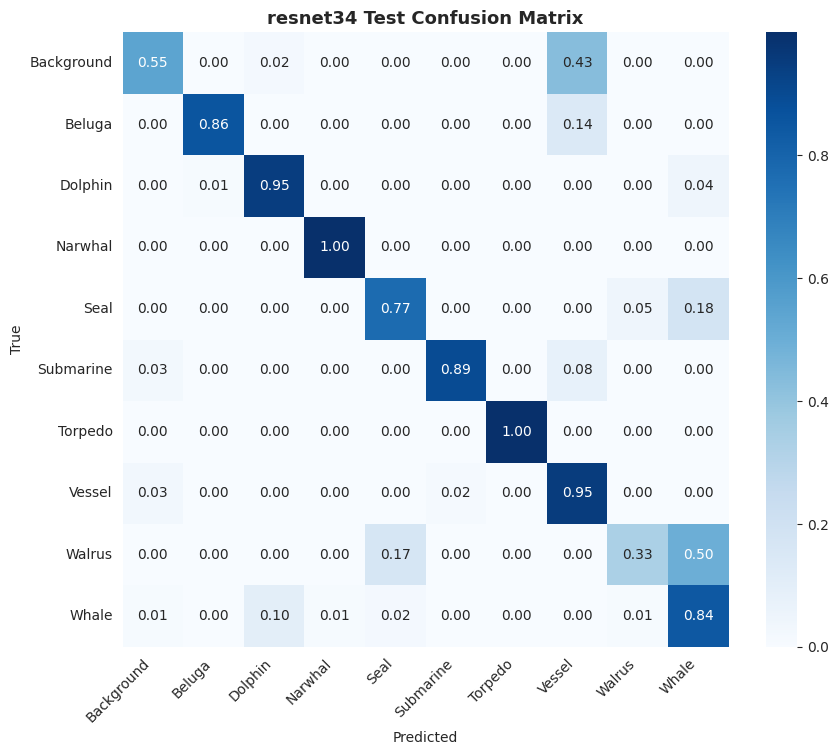


─── Test Results: squeezenet1_1 ───────────────────
  Accuracy  : 0.7878
  Precision : 0.4045
  Recall    : 0.4336
  F1 macro  : 0.4160
  Avg latency: 0.219 ms/sample
              precision    recall  f1-score   support

  Background       0.00      0.00      0.00        44
      Beluga       0.00      0.00      0.00         7
     Dolphin       0.67      0.94      0.78       116
     Narwhal       0.00      0.00      0.00         7
        Seal       0.00      0.00      0.00        22
   Submarine       0.89      0.82      0.85        38
     Torpedo       1.00      1.00      1.00        38
      Vessel       0.85      0.99      0.91       300
      Walrus       0.00      0.00      0.00         6
       Whale       0.64      0.59      0.62        96

    accuracy                           0.79       674
   macro avg       0.40      0.43      0.42       674
weighted avg       0.69      0.79      0.73       674



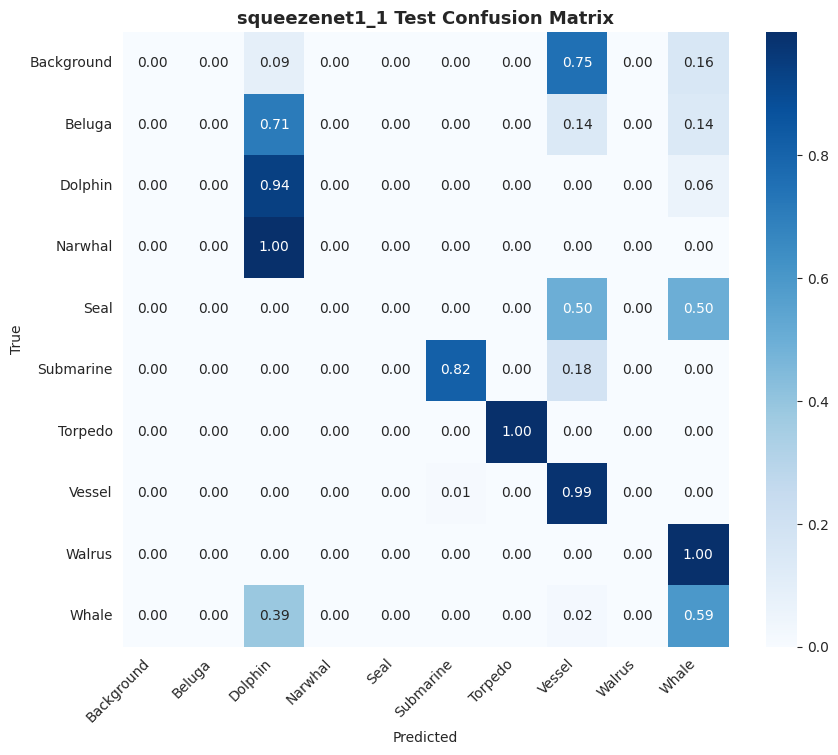


FINAL TEST SUMMARY
                    Accuracy  Precision  Recall      F1  Latency(ms)
Model                                                               
AcousticCNN           0.9021     0.8751  0.8123  0.8305       0.2759
resnet34              0.8961     0.8326  0.8145  0.8206       0.3214
resnet18              0.8798     0.8239  0.7483  0.7764       0.2426
mobilenet_v3_large    0.7582     0.6683  0.4593  0.4885       0.4937
efficientnet_b0       0.7774     0.5611  0.4715  0.4785       0.6943
efficientnet_b1       0.7493     0.4916  0.4291  0.4254       1.0174
mobilenet_v3_small    0.7611     0.5746  0.4171  0.4164       0.4759
squeezenet1_1         0.7878     0.4045  0.4336  0.4160       0.2191


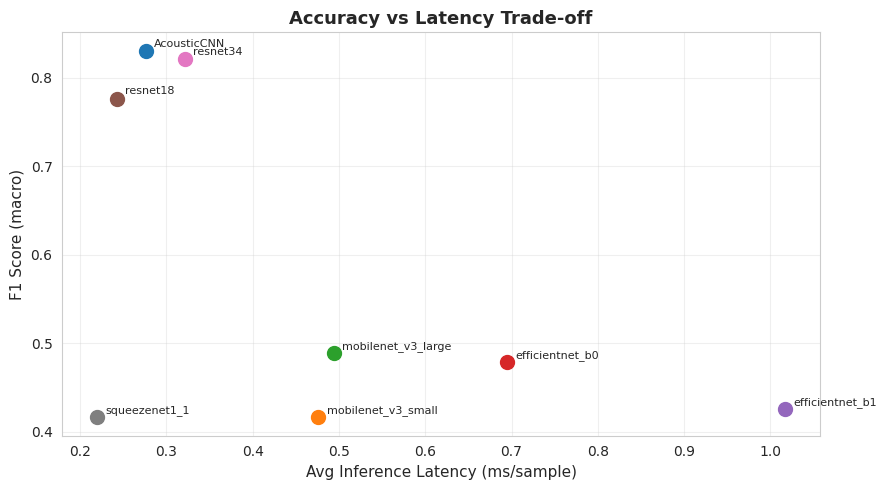

In [17]:
# ── Single file inference ─────────────────────────────────────
def predict_file(model, audio_path: str, cfg: AudioConfig, device=DEVICE) -> dict:
    """Run inference on a single WAV file."""
    model.eval()
    sig, sr = torchaudio.load(audio_path)
    if sr != cfg.sample_rate:
        sig = T.Resample(sr, cfg.sample_rate)(sig)
    if sig.shape[0] > 1:
        sig = sig.mean(dim=0, keepdim=True)

    n = cfg.max_samples
    if sig.shape[1] >= n:
        sig = sig[:, :n]
    else:
        sig = F.pad(sig, (0, n - sig.shape[1]))

    mel = T.MelSpectrogram(sample_rate=cfg.sample_rate, n_fft=cfg.n_fft,
                           hop_length=cfg.hop_length, n_mels=cfg.n_mels)(sig)
    spec = T.AmplitudeToDB(top_db=cfg.top_db)(mel).unsqueeze(0).to(device)  # (1,1,F,T)

    with torch.no_grad():
        logits = model(spec)
        probs  = F.softmax(logits, dim=1).squeeze(0).cpu().numpy()

    pred_idx = probs.argmax()
    return {
        'predicted_class': CLASS_NAMES[pred_idx],
        'confidence':      float(probs[pred_idx]),
        'all_probs':       {cls: float(p) for cls, p in zip(CLASS_NAMES, probs)}
    }


# ── Batch inference on a folder ───────────────────────────────
def predict_folder(model, folder_path: str, cfg: AudioConfig,
                   device=DEVICE) -> pd.DataFrame:
    """Run inference on all WAV files in a folder."""
    files = [f for f in os.listdir(folder_path) if f.endswith('.wav')]
    records = []
    for fname in tqdm(files, desc='Inference'):
        path = os.path.join(folder_path, fname)
        try:
            result = predict_file(model, path, cfg, device)
            records.append({
                'file':             fname,
                'predicted_class':  result['predicted_class'],
                'confidence':       result['confidence'],
                **{f'p_{cls}': result['all_probs'][cls] for cls in CLASS_NAMES}
            })
        except Exception as e:
            print(f'[WARN] {fname}: {e}')
    return pd.DataFrame(records)


# ── Full test-set evaluation with timing ─────────────────────
def test_model(model, loader, model_name: str, device=DEVICE) -> dict:
    """Evaluate on test loader and measure inference time."""
    import time
    model.eval()
    preds, labels = [], []
    times = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            t0 = time.perf_counter()
            out = model(x)
            times.append((time.perf_counter() - t0) / x.size(0))  # per sample
            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(y.numpy())

    labels, preds = np.array(labels), np.array(preds)
    results = {
        'model':          model_name,
        'accuracy':       accuracy_score(labels, preds),
        'precision':      precision_score(labels, preds, average='macro', zero_division=0),
        'recall':         recall_score(labels, preds, average='macro', zero_division=0),
        'f1':             f1_score(labels, preds, average='macro', zero_division=0),
        'avg_ms':         np.mean(times) * 1000,   # milliseconds per sample
        'labels':         labels,
        'preds':          preds,
    }

    print(f'\n─── Test Results: {model_name} ───────────────────')
    print(f'  Accuracy  : {results["accuracy"]:.4f}')
    print(f'  Precision : {results["precision"]:.4f}')
    print(f'  Recall    : {results["recall"]:.4f}')
    print(f'  F1 macro  : {results["f1"]:.4f}')
    print(f'  Avg latency: {results["avg_ms"]:.3f} ms/sample')
    print(classification_report(labels, preds, target_names=CLASS_NAMES, zero_division=0))
    plot_confusion(labels, preds, CLASS_NAMES, title=f'{model_name} Test Confusion Matrix')

    return results


# ── Run testing on all models ─────────────────────────────────
# Using val_loader as test set here — swap in a held-out test_loader if you have one
test_results = {}

# AcousticCNN
test_results['AcousticCNN'] = test_model(model_cnn, val_loader, 'AcousticCNN')

# All pretrained backbones — reload best checkpoint before testing
for backbone_name in BACKBONES:
    m = PretrainedAcoustic(num_classes=NUM_CLASSES, backbone_name=backbone_name).to(DEVICE)
    m.load_state_dict(torch.load(f'best_{backbone_name}.pth'))
    test_results[backbone_name] = test_model(m, val_loader, backbone_name)
    del m
    gc.collect()


# ── Final test summary table ──────────────────────────────────
summary = pd.DataFrame([
    {
        'Model':     name,
        'Accuracy':  r['accuracy'],
        'Precision': r['precision'],
        'Recall':    r['recall'],
        'F1':        r['f1'],
        'Latency(ms)': r['avg_ms'],
    }
    for name, r in test_results.items()
]).set_index('Model').sort_values('F1', ascending=False)

print('\n' + '='*60)
print('FINAL TEST SUMMARY')
print('='*60)
print(summary.round(4).to_string())

# Plot latency vs F1 — useful figure for paper
fig, ax = plt.subplots(figsize=(9, 5))
for name, r in test_results.items():
    ax.scatter(r['avg_ms'], r['f1'], s=100, zorder=5)
    ax.annotate(name, (r['avg_ms'], r['f1']),
                textcoords='offset points', xytext=(6, 3), fontsize=8)
ax.set_xlabel('Avg Inference Latency (ms/sample)', fontsize=11)
ax.set_ylabel('F1 Score (macro)', fontsize=11)
ax.set_title('Accuracy vs Latency Trade-off', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('latency_vs_f1.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Single file demo ──────────────────────────────────────────
# Uncomment and set path to test on one file:
# result = predict_file(model_cnn, '/path/to/your/file.wav', CFG)
# print(f'Predicted: {result["predicted_class"]}  ({result["confidence"]*100:.1f}%)')
# for cls, prob in sorted(result["all_probs"].items(), key=lambda x: -x[1]):
#     print(f'  {cls:20s}: {prob*100:.2f}%')

In [19]:
import os
import zipfile
from pathlib import Path

def flatten_and_zip_filtered(source_dir, extensions=(".png", ".pth"), zip_filename="selected_files.zip"):
    """
    Recursively collect only files with given extensions from source_dir,
    and add them to a zip file without preserving directory structure.
    Duplicate flat names are resolved by replacing path separators with underscores.
    """
    source_dir = Path(source_dir).resolve()
    zip_path = source_dir / zip_filename

    # Remove existing zip to avoid including itself
    if zip_path.exists():
        os.remove(zip_path)

    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
        count = 0
        for root, dirs, files in os.walk(source_dir):
            for file in files:
                # Check extension (case-insensitive)
                if not file.lower().endswith(extensions):
                    continue

                full_path = Path(root) / file
                if full_path == zip_path:
                    continue

                # Relative path from source_dir
                rel_path = full_path.relative_to(source_dir)
                # Flatten: replace separators with underscores
                flat_name = str(rel_path).replace(os.sep, '_')
                zf.write(full_path, arcname=flat_name)
                count += 1

    print(f"✅ Zipped {count} files with extensions {extensions} into: {zip_path}")
    print(f"📦 Download '{zip_filename}' from the file browser.")

# Run the function – only .png and .pth files
flatten_and_zip_filtered("/kaggle/working")

✅ Zipped 34 files with extensions ('.png', '.pth') into: /kaggle/working/selected_files.zip
📦 Download 'selected_files.zip' from the file browser.
